# ML модель предсказание вероятности клика на платформе рекламного аукциона 

## Структура проекта

### Цель исследования 

Цель проекта — разработать модель бинарной классификации, которая будет предсказывать вероятность клика пользователя по рекламному объявлению (CTR), а затем откалибровать полученные вероятности.

### Описание исследования 

Для рекламной платформы Advandex важно не только правильно определить, какие объявления с большей вероятностью получат клик, но и получать достоверные значения вероятности. Например, если модель прогнозирует CTR на уровне 20%, то в достаточно большой группе похожих показов клик должен происходить примерно в 20% случаев.

Точность предсказанных вероятностей имеет непосредственное влияние на рекламные аукционы. Завышение CTR может привести к переплате за показы и неэффективному расходованию рекламного бюджета, а занижение — к проигрышу потенциально выгодных аукционов и упущенному доходу.

Таким образом, исследование состоит из двух основных частей:
построение модели бинарной классификации для прогнозирования клика;
калибровка вероятностных предсказаний для повышения их соответствия фактической частоте кликов.

### Задачи исследования 

* Загрузить и изучить исходный датасет с данными о показах рекламных объявлений.
* Изучить структуру данных, типы признаков, размер выборки и количество уникальных значений.
* Проанализировать целевую переменную `click` и оценить степень дисбаланса классов.
* Исследовать наличие пропущенных значений и определить подходящие способы их обработки.
* Провести исследовательский анализ данных и изучить взаимосвязь признаков с вероятностью клика.
* Разделить признаки на числовые и категориальные.
* Выполнить необходимую предобработку данных:

  * заполнить пропуски в числовых признаках;
  * обработать пропуски в категориальных признаках;
  * масштабировать числовые признаки;
  * применить One-Hot Encoding для низкокардинальных категорий;
  * применить Target Encoding для высококардинальных признаков.
* Провести отбор наиболее информативных признаков с использованием фильтрационного метода.
* Применить wrapper-метод отбора признаков и сравнить результаты.
* Построить baseline-модель для определения исходного уровня качества.
* Обучить модель логистической регрессии для прогнозирования вероятности клика.
* Обучить модель SVM с линейным ядром.
* Выполнить подбор гиперпараметров моделей с помощью `GridSearchCV`.
* Оценить модели по основным метрикам:

  * PR-AUC;
  * Log Loss;
  * Brier Score.
* Дополнительно оценить Precision, Recall и F1-score.
* Исследовать качество исходной калибровки вероятностных прогнозов.
* Построить диаграммы калибровки (`Calibration Curve`).
* Выполнить калибровку лучшей модели с помощью изотонической регрессии.
* Сравнить качество прогнозов до и после калибровки.
* Рассчитать дополнительные метрики калибровки ECE и MCE.
* Проанализировать ошибки модели и случаи переоценки или недооценки CTR.
* Сравнить все протестированные модели и наборы признаков.
* Выбрать итоговую модель с оптимальным сочетанием качества классификации и достоверности вероятностных прогнозов.
* Сформулировать выводы о том, какие решения оказали наибольшее влияние на качество модели.
* Подготовить итоговый отчёт с финальными метриками, конфигурацией лучшей модели, графиками и бизнес-интерпретацией результатов.


### Исходные данные

Для исследования используется датасет ds_s16_ad_click_dataset, содержащий информацию об отдельных показах рекламных баннеров.
Каждая строка соответствует одному событию показа рекламы и содержит:
характеристики рекламной площадки;
характеристики рекламируемого приложения;
информацию об устройстве и типе соединения пользователя;
параметры рекламного баннера и аукциона;
временные признаки;
предварительно сгенерированные ML-признаки.
Целевая переменная — click:
- 1 — пользователь кликнул по рекламе;
- 0 — клика не произошло.

Данные анонимизированы, поэтому часть категориальных признаков представлена идентификаторами и кодами. Это не препятствует использованию признаков для машинного обучения, однако ограничивает их содержательную интерпретацию.


### Критерий успешности исследования

Исследование будет считаться успешным, если:
- построенная модель превосходит baseline по PR-AUC;
- вероятностные прогнозы имеют приемлемые значения Log Loss и Brier Score;
- после калибровки наблюдается улучшение соответствия прогнозируемых вероятностей фактической частоте кликов;
- выбранная модель демонстрирует разумный баланс между качеством классификации и качеством калибровки;
- все основные решения по предобработке, отбору признаков, выбору модели и калибровке подтверждены результатами экспериментов.

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [1]:
%pip install numpy pandas scikit- -q
%pip install matplotlib -q
%pip install seaborn -q
%pip install statsmodels -q



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
ERROR: Invalid requirement: 'scikit-': Expected end or semicolon (after name and no valid version specifier)
    scikit-
          ^
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip3 install phik -q



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [3]:
import sklearn
print(sklearn.__version__)

1.9.1


In [4]:
!pip3 install -U scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [5]:
import numpy as np
import phik
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

import joblib

RANDOM_STATE = 42

In [6]:
df = pd.read_csv('ds_s16_ad_click_dataset.csv')
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,0.172060,1.410256e+07,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,...,53173.383240,83.685180,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,0.377436,2.967892e+02,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,...,49960.181871,70.539513,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,...,-1.000000,13.000000,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,...,-1.000000,23.000000,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,...,100049.000000,61.000000,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,...,100094.000000,108.000000,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,...,100248.000000,255.000000,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300


## 2. Исследовательский анализ данных (EDA)



 ## 2.1 Базовая информация о датасете

В исследовании используется датасет с информацией о показах рекламных объявлений и взаимодействии пользователей с ними.

### Размер датасета

Датасет содержит:

* **50 000 объектов** — каждая строка соответствует одному событию показа рекламного баннера;
* **34 столбца**, включая целевую переменную `click`;
* следовательно, для построения модели используются **33 входных признака** и 1 целевая переменная.

В представленном датасете отсутствуют пропущенные значения: каждый из 50 000 объектов содержит значения по всем 34 столбцам.

### Типы данных

В датасете представлены следующие типы данных:

* **15 признаков типа `int64`**;
* **8 признаков типа `float64`**;
* **11 признаков типа `str`**.

При этом тип данных не всегда отражает смысл признака. Например, `banner_pos`, `device_type` и `device_conn_type` представлены как числовые значения, однако по смыслу являются категориальными признаками или кодами категорий. Поэтому при дальнейшей предобработке тип признака будет определяться не только по `dtype`, но и по его содержанию и количеству уникальных значений.

### Целевая переменная

Целевой переменной является `click`:

* `0` — клика по рекламному объявлению не произошло;
* `1` — пользователь кликнул по объявлению.

Среднее значение `click` составляет **0.172**, то есть доля кликов в выборке составляет около **17,2%**. Таким образом, положительный класс встречается существенно реже отрицательного, поэтому при оценке моделей основное внимание будет уделено метрике **PR-AUC**, которая подходит для задач бинарной классификации с дисбалансом классов.

### Информация о пользователе

Датасет содержит анонимизированную информацию, позволяющую описать контекст пользователя и его устройства:

* `device_id` — идентификатор устройства или браузера;
* `device_ip` — IP-адрес устройства;
* `device_model` — модель устройства;
* `device_type` — тип устройства;
* `device_conn_type` — тип сетевого подключения.

Эти признаки позволяют учитывать различия в поведении пользователей в зависимости от используемого устройства и типа подключения.

### Информация о рекламной площадке

Для описания площадки, на которой показывается реклама, используются:

* `site_id` — идентификатор сайта;
* `site_domain` — домен сайта;
* `site_category` — категория сайта.

Эти признаки характеризуют контекст рекламного показа и потенциально могут быть связаны с вероятностью клика.

### Информация о рекламируемом приложении

Для описания рекламируемого приложения представлены:

* `app_id` — идентификатор приложения;
* `app_domain` — домен приложения;
* `app_category` — категория приложения.

### Информация о рекламном баннере и аукционе

В датасете также присутствуют признаки, описывающие параметры рекламного показа:

* `banner_pos` — позиция рекламного баннера;
* `C1`;
* `C14`–`C21` — анонимизированные признаки, характеризующие параметры показа, пользователя, баннера или аукциона.

Кроме того, представлены предварительно сгенерированные ML-признаки:

* `ml_feature_1`;
* `ml_feature_3`–`ml_feature_6`;
* `ml_feature_8`–`ml_feature_10`.

### Временная информация

Признак `hour` содержит информацию о времени показа рекламного объявления в закодированном формате. Он потенциально позволяет учитывать временные закономерности в поведении пользователей и кликабельности рекламы.

### Общая характеристика

Таким образом, датасет представляет собой готовую аналитическую витрину, в которой для каждого показа рекламы объединены характеристики **пользователя и его устройства, рекламной площадки, рекламируемого приложения, баннера, параметров аукциона и времени показа**.

Основная задача дальнейшего исследования — определить, какие из этих признаков наиболее информативны для прогнозирования `click`, построить модель вероятности клика и затем проверить и улучшить калибровку полученных вероятностных прогнозов.


### 2.2 Анализ целевой переменной

In [8]:
df['click'].value_counts(normalize=True)

click
0    0.82794
1    0.17206
Name: proportion, dtype: float64

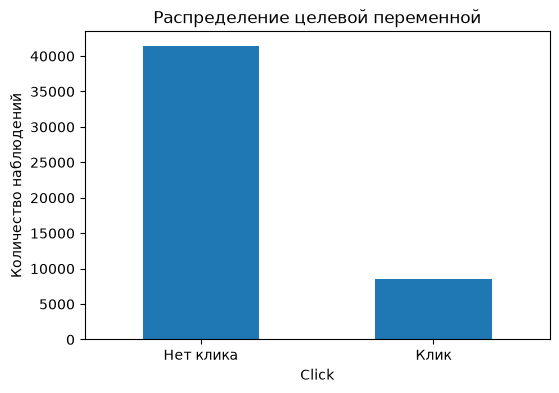

In [9]:
df['click'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Распределение целевой переменной')
plt.xlabel('Click')
plt.ylabel('Количество наблюдений')
plt.xticks([0, 1], ['Нет клика', 'Клик'], rotation=0)
plt.show()

Целевой переменной в исследовании является `click`, которая принимает два значения:

- `0` — пользователь не кликнул по рекламе;
- `1` — пользователь кликнул по рекламе.

В датасете 50 000 наблюдений. Доля объявлений, по которым был совершен клик, составляет около **17.21%**, тогда как доля объявлений без клика — около **82.79%**.

Таким образом, в данных присутствует **дисбаланс классов**: объектов класса 0 значительно больше, чем объектов класса 1. На один положительный случай приходится примерно четыре-пять отрицательных.

Наличие дисбаланса необходимо учитывать при выборе метрик качества. В качестве основной метрики для оценки моделей будет использоваться **PR-AUC**, поскольку она лучше отражает качество классификации положительного класса при несбалансированных данных. Дополнительно будут рассмотрены Log Loss, Brier Score, Precision, Recall и F1-score.

### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

In [10]:
# Полный набор признаков
numerical_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features.remove('click')  # Удаляем целевую переменную из списка признаков
numerical_features.remove('id')  # Удаляем идентификатор из списка признаков
full_feature_set = numerical_features + categorical_features


/var/folders/1c/tgs3pl0x32nfxds7kgdb1j4w0000gn/T/ipykernel_51137/898232231.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [11]:
full_feature_set

['hour',
 'C1',
 'banner_pos',
 'device_type',
 'device_conn_type',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'C19',
 'C20',
 'C21',
 'ml_feature_1',
 'ml_feature_3',
 'ml_feature_4',
 'ml_feature_5',
 'ml_feature_6',
 'ml_feature_8',
 'ml_feature_9',
 'ml_feature_10',
 'site_id',
 'site_domain',
 'site_category',
 'app_id',
 'app_domain',
 'app_category',
 'device_id',
 'device_ip',
 'device_model',
 'ml_feature_2',
 'ml_feature_7']

In [12]:
categorical_features

['site_id',
 'site_domain',
 'site_category',
 'app_id',
 'app_domain',
 'app_category',
 'device_id',
 'device_ip',
 'device_model',
 'ml_feature_2',
 'ml_feature_7']

In [13]:
numerical_features

['hour',
 'C1',
 'banner_pos',
 'device_type',
 'device_conn_type',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'C19',
 'C20',
 'C21',
 'ml_feature_1',
 'ml_feature_3',
 'ml_feature_4',
 'ml_feature_5',
 'ml_feature_6',
 'ml_feature_8',
 'ml_feature_9',
 'ml_feature_10']

### Удаление служебных и целевых признаков

Перед дальнейшим анализом и построением моделей были удалены признаки `click` и `id`.

Признак `click` является **целевой переменной**, которую необходимо предсказывать. Поэтому он не должен использоваться в качестве входного признака модели. При этом целевая переменная была сохранена отдельно для последующего разделения данных на признаки `X` и целевую переменную `y`.

Признак `id` был удалён, поскольку представляет собой **уникальный идентификатор наблюдения** и не содержит содержательной информации о характеристиках рекламного показа. Использование данного признака в модели может привести к выявлению случайных зависимостей и ухудшить обобщающую способность модели.

Таким образом, после удаления `id` и выделения `click` в качестве целевой переменной в дальнейшем анализе используются только информативные признаки, характеризующие рекламный показ, сайт, приложение, устройство, время и другие параметры.

### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

In [14]:
df[full_feature_set].isnull().sum()

hour                0
C1                  0
banner_pos          0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
ml_feature_1        0
ml_feature_3        0
ml_feature_4        0
ml_feature_5        0
ml_feature_6        0
ml_feature_8        0
ml_feature_9        0
ml_feature_10       0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
ml_feature_2        0
ml_feature_7        0
dtype: int64

Пропущенных значений нет 

### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

In [15]:
unique_counts_cat = df[categorical_features].nunique().sort_values(ascending=False)
unique_counts_cat

device_ip        41455
device_id         8580
device_model      2521
site_id           1160
site_domain       1013
app_id             976
app_domain          67
app_category        22
site_category       18
ml_feature_2         5
ml_feature_7         3
dtype: int64

In [16]:
# Признаки с небольшой кардинальностью
low_cardinality = unique_counts_cat[unique_counts_cat <= 20]

# Признаки с высокой кардинальностью
high_cardinality = unique_counts_cat[unique_counts_cat > 20]

print('Признаки для One-Hot Encoding:')
print(low_cardinality)

print('\nПризнаки с высокой кардинальностью:')
print(high_cardinality)

Признаки для One-Hot Encoding:
site_category    18
ml_feature_2      5
ml_feature_7      3
dtype: int64

Признаки с высокой кардинальностью:
device_ip       41455
device_id        8580
device_model     2521
site_id          1160
site_domain      1013
app_id            976
app_domain         67
app_category       22
dtype: int64


### Анализ кардинальности категориальных признаков

По результатам анализа количества уникальных значений категориальные признаки были разделены на две группы в зависимости от их кардинальности.

**Признаки с низкой кардинальностью**, для которых целесообразно использовать **One-Hot Encoding**:

| Признак         | Количество уникальных значений |
| --------------- | -----------------------------: |
| `ml_feature_7`  |                              3 |
| `ml_feature_2`  |                              5 |
| `site_category` |                             18 |

Эти признаки содержат небольшое количество категорий, поэтому их кодирование методом One-Hot Encoding не приведёт к существенному увеличению размерности набора данных.

**Признаки с высокой кардинальностью**:

| Признак        | Количество уникальных значений |
| -------------- | -----------------------------: |
| `app_category` |                             22 |
| `app_domain`   |                             67 |
| `app_id`       |                            976 |
| `site_domain`  |                          1 013 |
| `site_id`      |                          1 160 |
| `device_model` |                          2 521 |
| `device_id`    |                          8 580 |
| `device_ip`    |                         41 455 |

Для этих признаков применение One-Hot Encoding напрямую может привести к значительному увеличению количества признаков и разреженности данных. Поэтому для них целесообразно рассмотреть **Target Encoding** или другие методы кодирования категориальных признаков высокой кардинальности.

Особенно высокая кардинальность наблюдается у `device_ip` (41 455 уникальных значений) и `device_id` (8 580 уникальных значений). Использование OHE для таких признаков нецелесообразно, поскольку практически каждое наблюдение будет соответствовать отдельной категории.

Таким образом, для дальнейшего построения модели выбрано следующее разделение:

* **One-Hot Encoding:** `site_category`, `ml_feature_2`, `ml_feature_7`;
* **Target Encoding:** `app_category`, `app_domain`, `app_id`, `site_domain`, `site_id`, `device_model`, `device_id`, `device_ip`.

Такое разделение позволяет сохранить информацию категориальных признаков, одновременно контролируя рост размерности пространства признаков.


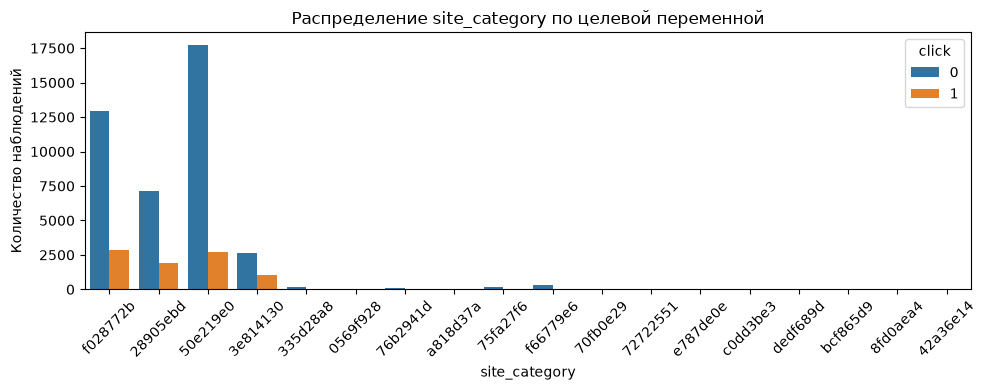

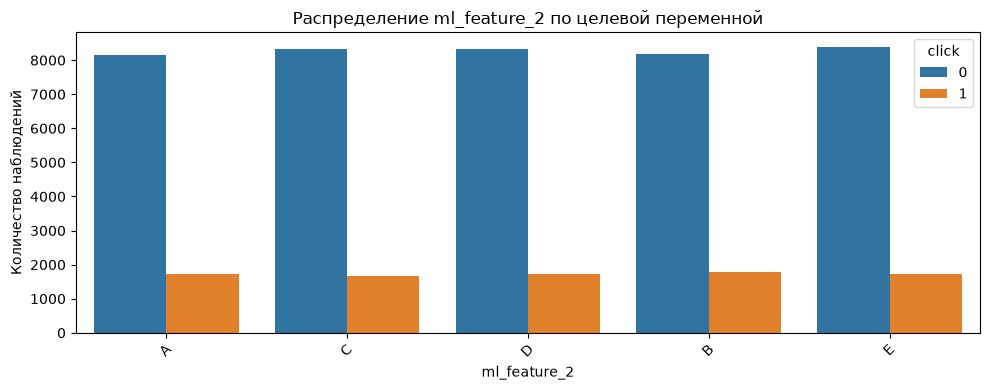

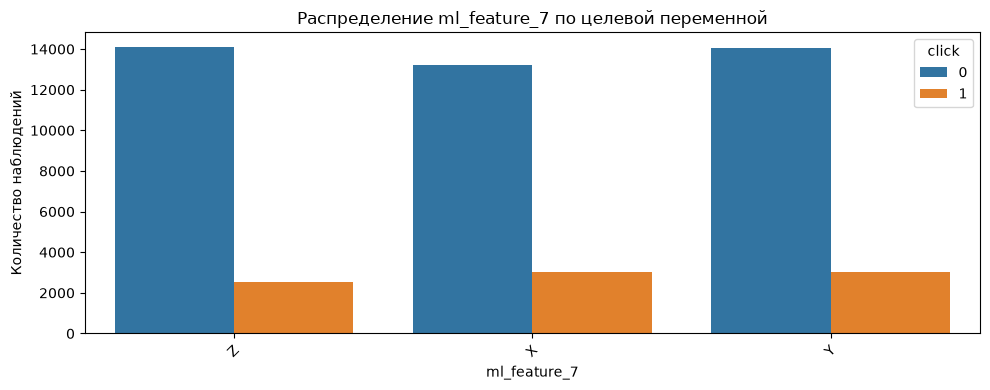

In [17]:
# Только признаки с небольшой кардинальностью
for feature in low_cardinality.index:
    plt.figure(figsize=(10, 4))
    
    sns.countplot(data=df, x=feature, hue='click')
    
    plt.title(f'Распределение {feature} по целевой переменной')
    plt.xlabel(feature)
    plt.ylabel('Количество наблюдений')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [18]:

df[low_cardinality.index].phik_matrix()

,site_category,ml_feature_2,ml_feature_7
site_category,1.000000,0.000000,0.015559
ml_feature_2,0.000000,1.000000,0.005352
ml_feature_7,0.015559,0.005352,1.000000


### Анализ взаимосвязи категориальных признаков

Для оценки возможной избыточности признаков была рассчитана корреляция между `site_category`, `ml_feature_2` и `ml_feature_7`.

Полученные значения корреляции:

| Признаки                         | Корреляция |
| -------------------------------- | ---------: |
| `site_category` — `ml_feature_2` |     0.0000 |
| `site_category` — `ml_feature_7` |     0.0156 |
| `ml_feature_2` — `ml_feature_7`  |     0.0054 |

Все значения находятся вблизи нуля, что свидетельствует об **отсутствии выраженной линейной взаимосвязи между данными признаками**.

Таким образом, несмотря на визуально похожее распределение `ml_feature_2` и `ml_feature_7` относительно целевой переменной `click`, признаки не являются сильно коррелирующими между собой. Поэтому на данном этапе **удалять их нецелесообразно**.

Оба признака будут сохранены для дальнейшего моделирования. Их необходимость и вклад в качество модели дополнительно будут оценены на этапе **отбора признаков (Feature Selection)**.


### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

In [19]:
#Найдем выбросы в признаках
df[numerical_features].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
hour,1.410256e+07,296.789151,1.410210e+07,1.410230e+07,1.410260e+07,1.410281e+07,1.410302e+07
C1,1.004970e+03,1.110202,1.001000e+03,1.005000e+03,1.005000e+03,1.005000e+03,1.012000e+03
banner_pos,2.913800e-01,0.514201,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,7.000000e+00
device_type,1.018120e+00,0.538477,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
device_conn_type,3.371600e-01,0.860057,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
C14,1.882665e+04,4983.064178,3.750000e+02,1.692000e+04,2.034600e+04,2.191600e+04,2.404300e+04
C15,3.188664e+02,20.561530,1.200000e+02,3.200000e+02,3.200000e+02,3.200000e+02,1.024000e+03
C16,5.969248e+01,46.720842,2.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,1.024000e+03
C17,2.109781e+03,612.963141,1.120000e+02,1.823000e+03,2.323000e+03,2.526000e+03,2.757000e+03
C18,1.428100e+00,1.327413,0.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00


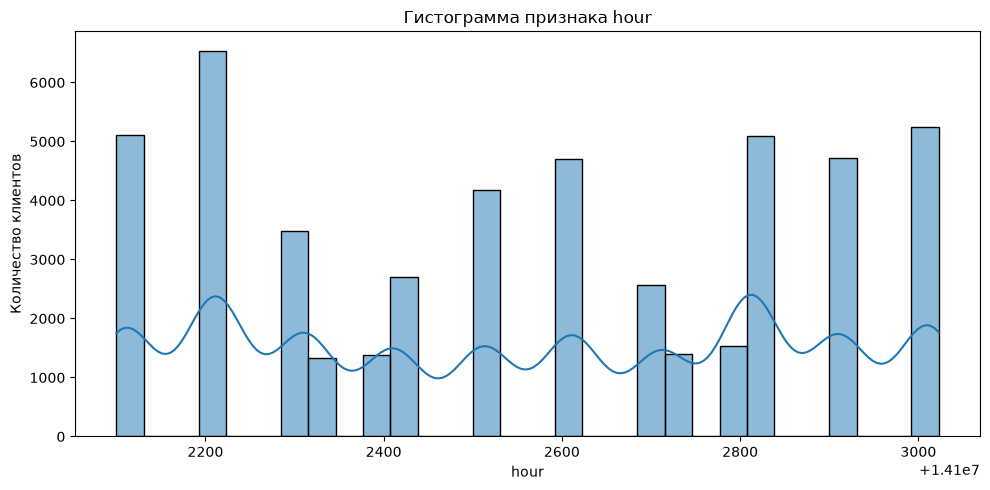

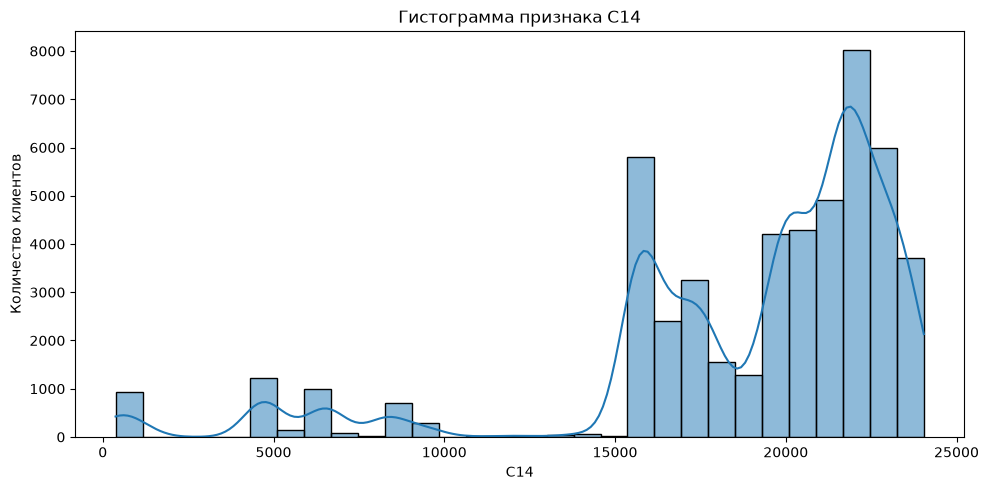

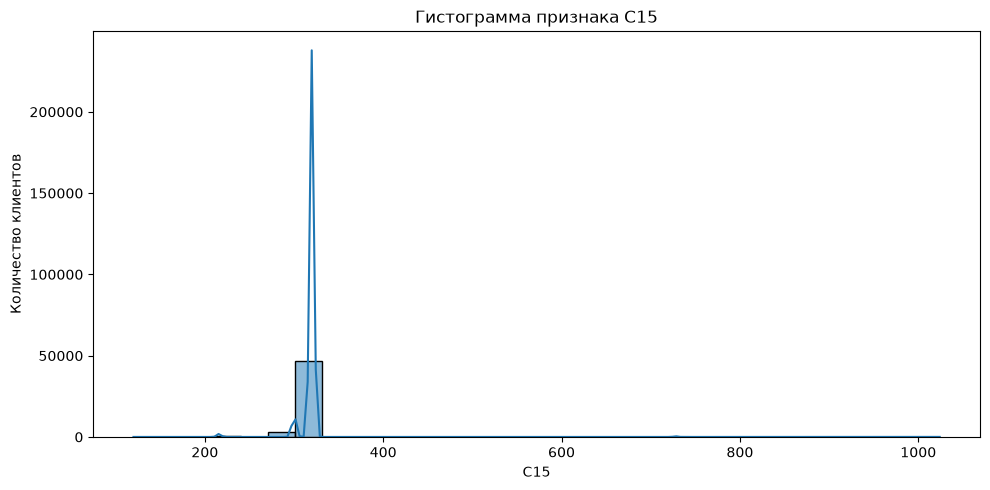

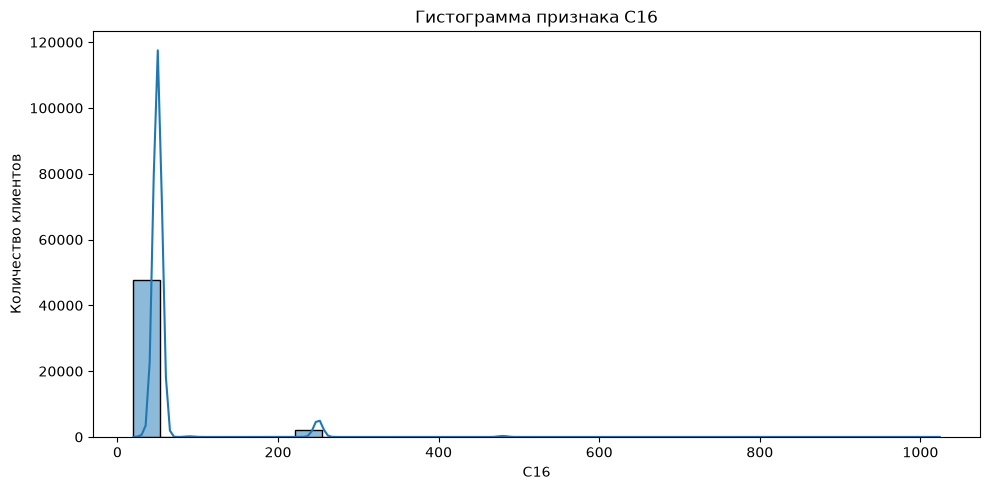

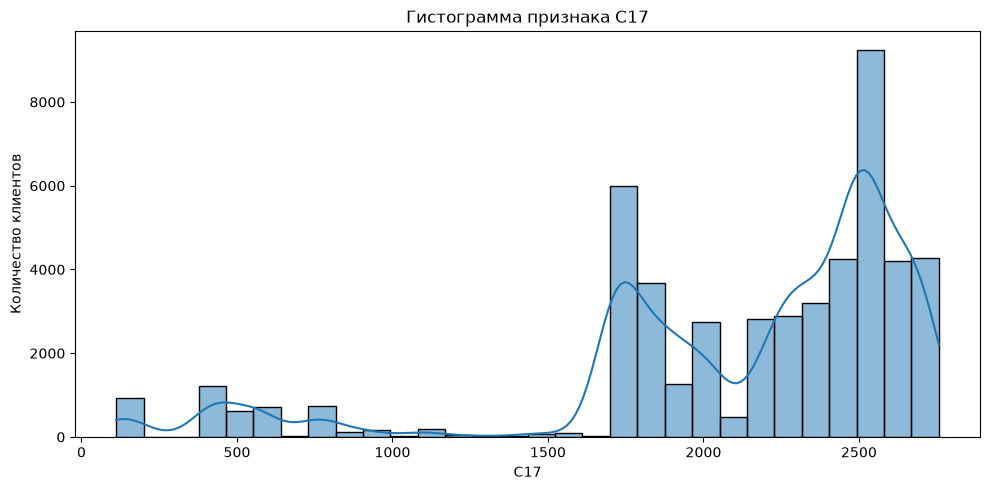

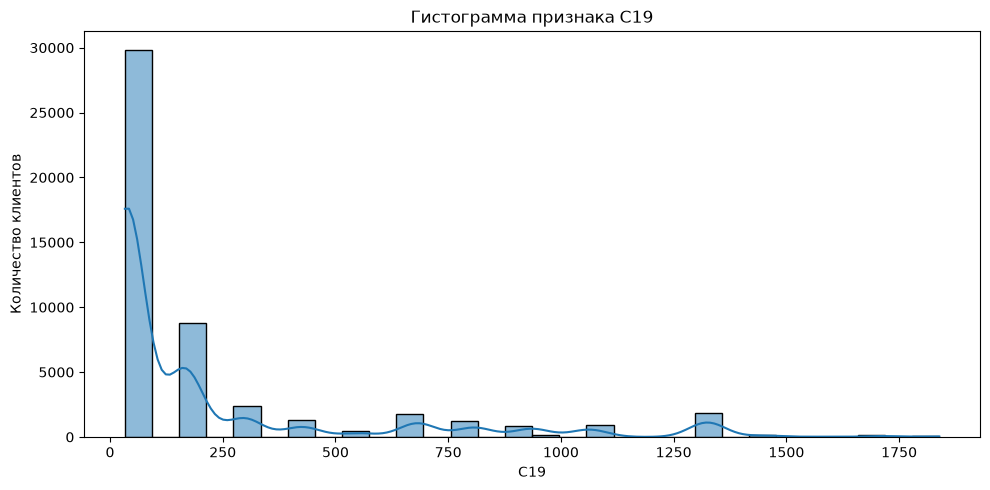

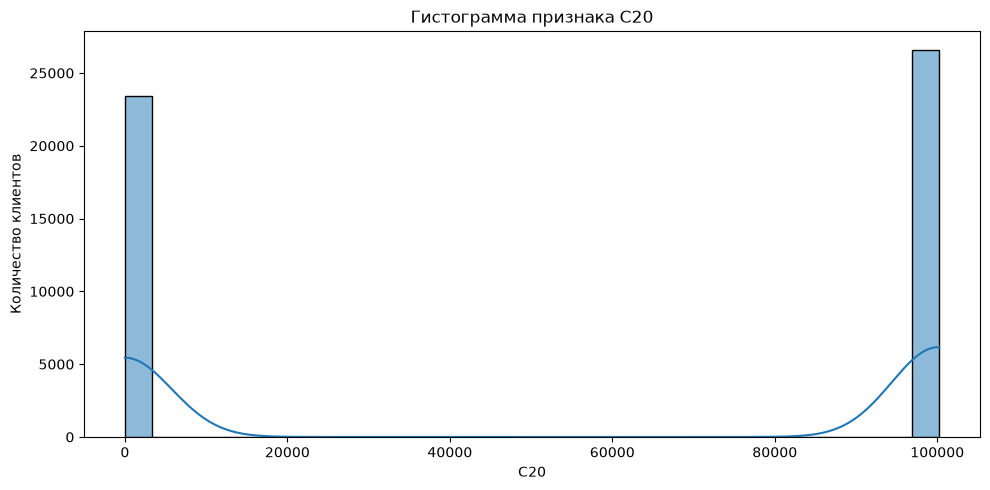

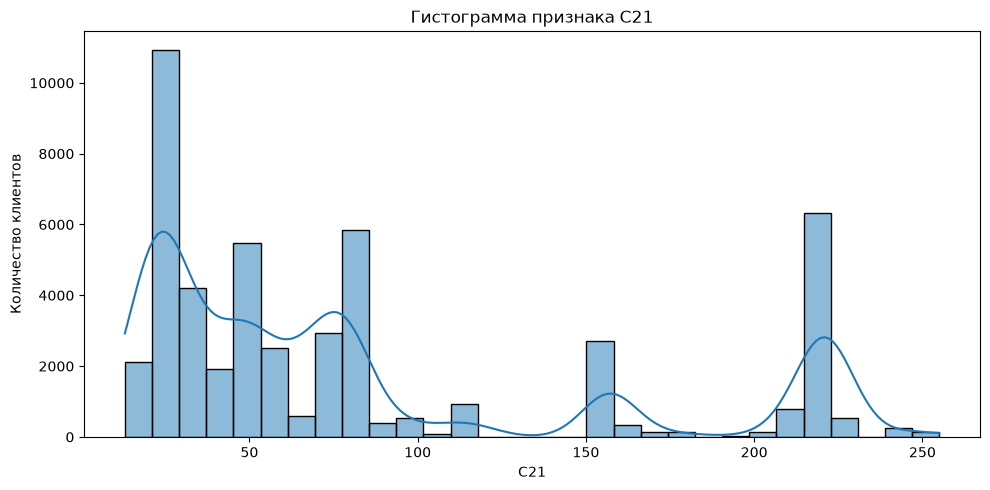

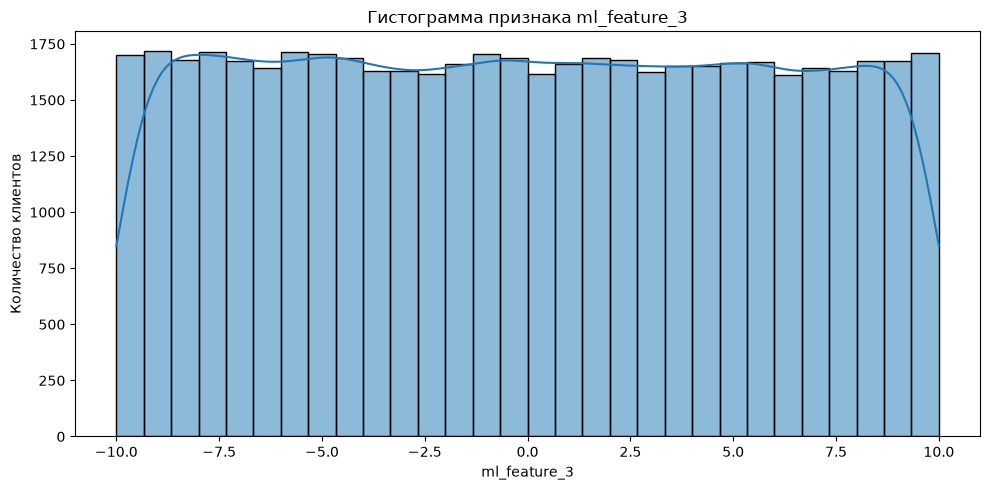

In [20]:
#Сделаем гистрограммы признаков с высоким std, чтобы визуально определить выбросы

high_std_features = df[numerical_features].std()
high_std_features = high_std_features[high_std_features > 5].index

for feature in high_std_features:
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True
    )
    
    plt.title(f'Гистограмма признака {feature}')
    plt.xlabel(feature)
    plt.ylabel('Количество клиентов')
    plt.tight_layout()
    plt.show()

In [21]:
# Посчитаем количество выбросов выше верхней границы для признаков с высоким std
# Посчитаем количество выбросов выше 99-го перцентиля
outliers = {}

for feature in high_std_features:
    percentile_99 = df[feature].quantile(0.99)
    outliers[feature] = (df[feature] > percentile_99).sum()

display(pd.Series(outliers, name='Количество выбросов выше 99-го перцентиля'))

hour            360
C14             490
C15              87
C16             132
C17             489
C19             384
C20             482
C21             379
ml_feature_3    500
Name: Количество выбросов выше 99-го перцентиля, dtype: int64

### Выводы по анализу выбросов

Для числовых признаков было проведено выявление потенциальных выбросов по значению выше **99-го перцентиля**. Получены следующие результаты:

| Признак        | Количество потенциальных выбросов |
| -------------- | --------------------------------: |
| `C14`          |                               490 |
| `C17`          |                               489 |
| `C20`          |                               482 |
| `C21`          |                               379 |
| `C19`          |                               384 |
| `hour`         |                               360 |
| `C16`          |                               132 |
| `C15`          |                                87 |
| `ml_feature_3` |                               500 |

Наибольшее количество значений выше 99-го перцентиля наблюдается у `ml_feature_3` — **500 наблюдений**, что соответствует ожидаемым примерно 1% выборки. Аналогичная ситуация наблюдается у `C14`, `C17`, `C20` и других признаков.

Важно отметить, что в данном случае значения выше 99-го перцентиля **не обязательно являются ошибочными или аномальными**. Они могут соответствовать редким характеристикам рекламных показов. Поэтому удалять такие наблюдения автоматически нецелесообразно.

Отдельного внимания требует признак `hour`. Его значения имеют специальный формат, отражающий дату и час показа рекламы, поэтому применение стандартного подхода к обработке выбросов для него некорректно. Данный признак необходимо рассматривать как **временную характеристику**, а не как обычный непрерывный числовой признак.

Таким образом, на данном этапе **выбросы удаляться не будут**. Потенциальные экстремальные значения сохраняются, поскольку они могут содержать полезную информацию для прогнозирования клика. При необходимости их влияние будет дополнительно оценено в процессе построения и сравнения моделей.


### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.


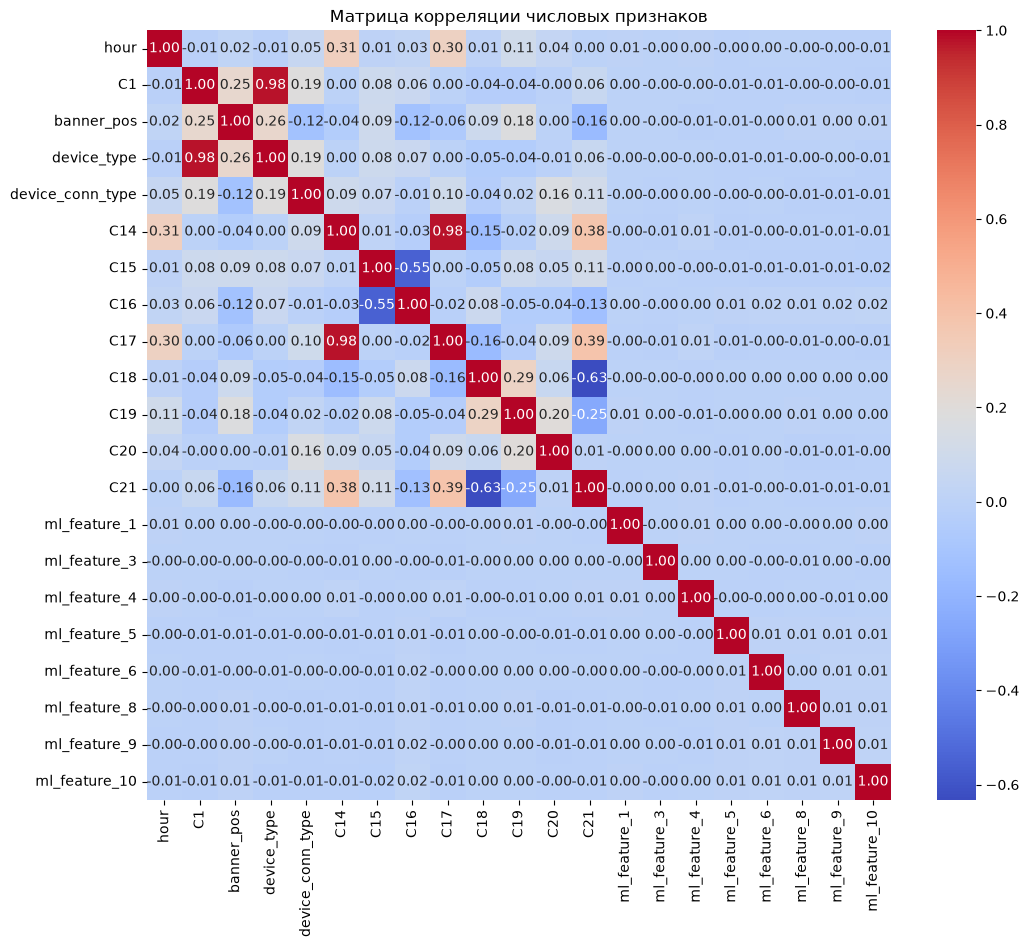

In [22]:
#Найдем корреляцию между числовыми признаками с помощью метода Спирмена и визуализируем ее с помощью тепловой карты
corr_features=df[numerical_features].corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_features, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Матрица корреляции числовых признаков')
plt.show()

In [23]:
#Найдем корреляцию для категориальных признаков корреляционный анализ с помощью коэффициента Крамера (Cramér's V)
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    
    r, k = confusion_matrix.shape
    
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(
        phi2corr / min((kcorr - 1), (rcorr - 1))
    )

df_sample = df.sample(n=10000, random_state=42)

categorical_features = df_sample.select_dtypes(
    include=['object', 'str']
).columns

cramers_matrix = pd.DataFrame(
    index=categorical_features,
    columns=categorical_features,
    dtype=float
)

for col1 in categorical_features:
    for col2 in categorical_features:
        cramers_matrix.loc[col1, col2] = cramers_v(
            df_sample[col1],
            df_sample[col2]
        )

cramers_matrix

,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,ml_feature_2,ml_feature_7
site_id,1.000000,0.944745,0.937769,0.000000,0.000000,0.023045,0.465114,0.243266,0.301847,0.007064,0.028218
site_domain,0.944745,1.000000,0.840861,0.000000,0.000000,0.087140,0.476644,0.243499,0.291023,0.024745,0.000000
site_category,0.937769,0.840861,1.000000,0.107298,0.207496,0.225908,0.000000,0.235934,0.302423,0.000000,0.019109
app_id,0.000000,0.000000,0.107298,1.000000,0.980077,0.979094,0.595042,0.199074,0.313413,0.000000,0.021986
app_domain,0.000000,0.000000,0.207496,0.980077,1.000000,0.533883,0.512817,0.240445,0.552894,0.000000,0.000000
app_category,0.023045,0.087140,0.225908,0.979094,0.533883,1.000000,0.635883,0.000000,0.313111,0.000000,0.000000
device_id,0.465114,0.476644,0.000000,0.595042,0.512817,0.635883,1.000000,0.268227,0.345041,0.006943,0.021762
device_ip,0.243266,0.243499,0.235934,0.199074,0.240445,0.000000,0.268227,1.000000,0.257216,0.000000,0.039722
device_model,0.301847,0.291023,0.302423,0.313413,0.552894,0.313111,0.345041,0.257216,1.000000,0.000000,0.000000
ml_feature_2,0.007064,0.024745,0.000000,0.000000,0.000000,0.000000,0.006943,0.000000,0.000000,1.000000,0.000000


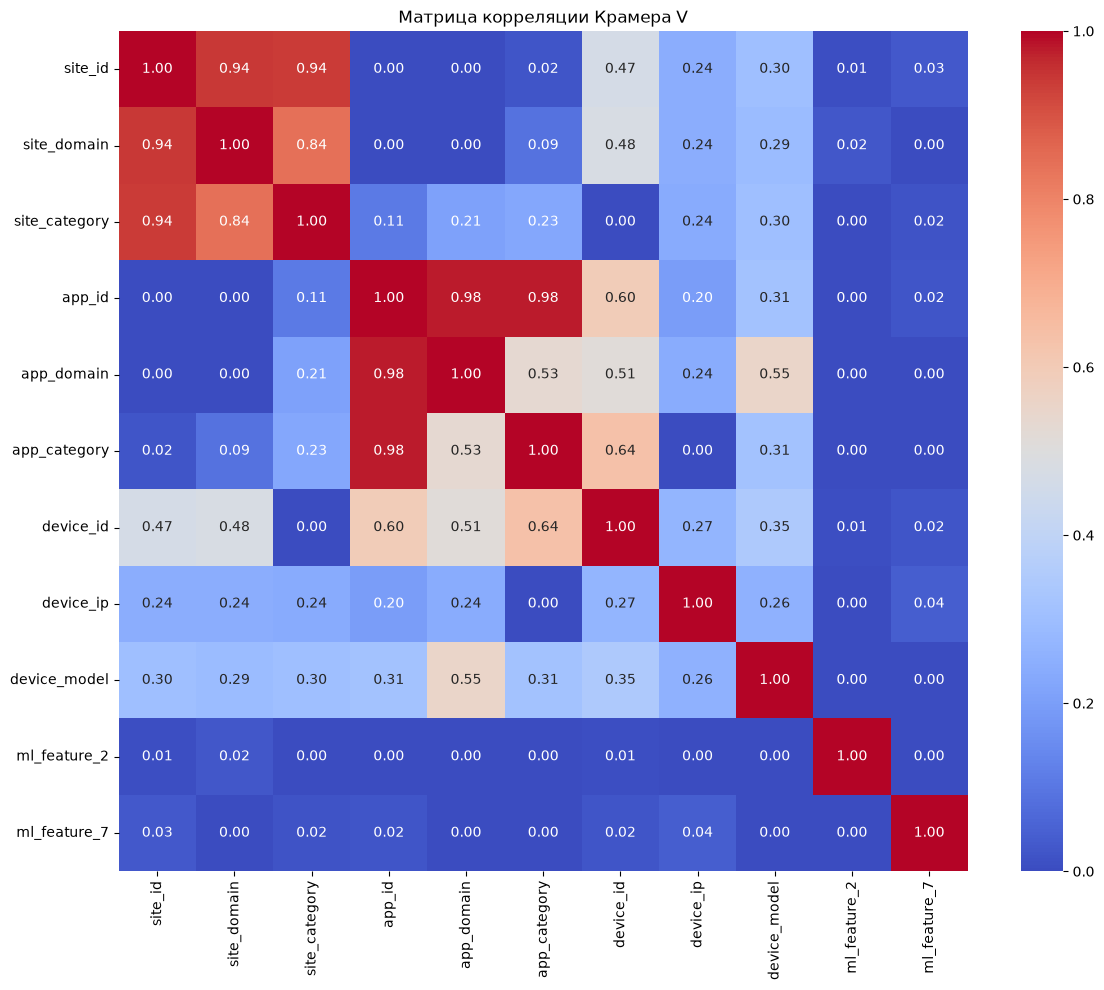

In [24]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1
)

plt.title('Матрица корреляции Крамера V')
plt.tight_layout()
plt.show()

In [25]:
#Определим целевую переменную и признаки
target = 'click'
features = df.drop(columns=[target]).columns.tolist()
#Удалим из признаков id, так как это идентификатор клиента и не несет полезной информации для модели
features.remove('id')
df=df.drop(columns=['id'])
#Проверим данные 
df.head()

,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [26]:
#Выведем признаки с низкой корреляцией (Cramér's V < 0.1) с целевой переменной
low_corr_features = []
for feature in categorical_features:
    cramers_value = cramers_v(df[feature], df[target])
    if cramers_value < 0.1:
        low_corr_features.append(feature)

print("Признаки с низкой корреляцией (Cramér's V < 0.1):")
print(low_corr_features)

Признаки с низкой корреляцией (Cramér's V < 0.1):
['device_id', 'device_ip', 'ml_feature_2', 'ml_feature_7']


In [27]:
#Удалим категориальные признаки с низкой корреляцией (Cramér's V < 0.1) с целевой переменной и избыточные признаки 
df = df.drop(
    columns=['id', 'device_id', 'device_ip', 'ml_feature_2', 'ml_feature_7','app_id','site_id','site_domain'],
    errors='ignore'
) 
df.head()

,click,hour,C1,banner_pos,site_category,app_domain,app_category,device_model,device_type,device_conn_type,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
0,1,14102100,1005,1,f028772b,7801e8d9,07d7df22,31025cda,1,0,...,-1,33,-0.996823,0.666588,0,0.817292,0.993275,-0.619959,0.433666,0.274038
1,0,14102100,1005,0,28905ebd,7801e8d9,07d7df22,2ee63ff8,1,0,...,-1,79,-0.391309,5.146789,1,-0.883865,-0.825722,0.576526,-0.318558,-0.132851
2,0,14102100,1005,0,f028772b,7801e8d9,07d7df22,d780319b,1,0,...,100084,32,-2.112732,7.169348,0,-0.859440,-0.338365,-0.440047,-0.345412,0.340487
3,0,14102100,1005,0,50e219e0,d9b5648e,0f2161f8,f4fffcd0,1,0,...,100111,61,0.332707,-0.290708,1,0.062795,0.062934,0.551982,0.733382,-0.198542
4,0,14102100,1005,0,28905ebd,7801e8d9,07d7df22,a0f5f879,1,0,...,100084,79,1.166623,6.319134,1,-0.675276,0.797144,0.640827,0.297955,-0.136909


### Выводы по корреляции Крамера

Для оценки взаимосвязи между категориальными признаками была рассчитана матрица коэффициентов Крамера V. Коэффициент принимает значения от 0 до 1: значения, близкие к 0, указывают на слабую или отсутствующую зависимость, а значения, близкие к 1, — на сильную взаимосвязь между признаками.

После удаления признаков с очень слабой корреляцией с целевой переменной `click` в оставшемся наборе данных были обнаружены несколько групп признаков с выраженной взаимосвязью:

* `app_id` и `app_domain` — **0.98**;
* `app_id` и `app_category` — **0.98**;
* `site_id` и `site_domain` — **0.94**;
* `site_id` и `site_category` — **0.94**;
* `site_domain` и `site_category` — **0.84**.

Высокие значения коэффициента Крамера V указывают на значительную зависимость между признаками. Например, `app_id` практически однозначно связан с определёнными `app_domain` и `app_category`. Аналогичная зависимость наблюдается между `site_id`, `site_domain` и `site_category`.

Такая взаимосвязь свидетельствует о наличии **признаковой избыточности**: часть информации может дублироваться в нескольких признаках. Это особенно важно учитывать при кодировании категориальных переменных, поскольку применение One-Hot Encoding ко всем взаимосвязанным признакам может существенно увеличить размерность данных.


In [28]:
#Найдем корреляцию между числовыми признаками и целевой переменной
correlation_with_target = df[numerical_features + [target]].corr(method='spearman')[target].sort_values(ascending=False)
display(correlation_with_target) 

click               1.000000
ml_feature_9        0.140747
C16                 0.130813
ml_feature_10       0.126674
ml_feature_8        0.077923
ml_feature_6        0.071870
ml_feature_5        0.060347
banner_pos          0.023058
C18                 0.008595
ml_feature_3        0.002936
ml_feature_1        0.000867
ml_feature_4       -0.003141
C19                -0.012409
hour               -0.014598
device_type        -0.047774
C1                 -0.048757
C20                -0.064544
C17                -0.064827
C14                -0.072136
device_conn_type   -0.076268
C21                -0.084017
C15                -0.112777
Name: click, dtype: float64

### Анализ корреляции числовых признаков с целевой переменной

Для оценки линейной взаимосвязи числовых признаков с целевой переменной `click` была рассчитана корреляция Пирсона.

Наиболее выраженную **положительную корреляцию** с вероятностью клика имеют:

* `ml_feature_9` — **0.141**;
* `C16` — **0.131**;
* `ml_feature_10` — **0.127**;
* `ml_feature_8` — **0.078**;
* `ml_feature_6` — **0.072**.

Наиболее заметную **отрицательную корреляцию** имеют:

* `C15` — **−0.113**;
* `C21` — **−0.084**;
* `C17` — **−0.065**;
* `C20` — **−0.065**;
* `C14` — **−0.072**;
* `device_conn_type` — **−0.076**.

При этом абсолютные значения коэффициентов в целом невелики. Даже максимальная по модулю корреляция (`ml_feature_9` — 0.141) указывает лишь на слабую линейную связь с целевой переменной.




In [29]:
#Найдем все признаки с низкой корреляцией с целевой переменной (по модулю меньше 0.05)
low_correlation_features = correlation_with_target[
    correlation_with_target.abs() < 0.05
].index.tolist()

low_correlation_features

['banner_pos',
 'C18',
 'ml_feature_3',
 'ml_feature_1',
 'ml_feature_4',
 'C19',
 'hour',
 'device_type',
 'C1']

In [30]:
#Удалим признаки с низкой корреляцией с целевой переменной из набора признаков
df.drop(columns=low_correlation_features, inplace=True)
df.head()

,click,site_category,app_domain,app_category,device_model,device_conn_type,C14,C15,C16,C17,C20,C21,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
0,1,f028772b,7801e8d9,07d7df22,31025cda,0,17614,320,50,1993,-1,33,0.817292,0.993275,-0.619959,0.433666,0.274038
1,0,28905ebd,7801e8d9,07d7df22,2ee63ff8,0,15701,320,50,1722,-1,79,-0.883865,-0.825722,0.576526,-0.318558,-0.132851
2,0,f028772b,7801e8d9,07d7df22,d780319b,0,17914,320,50,2043,100084,32,-0.859440,-0.338365,-0.440047,-0.345412,0.340487
3,0,50e219e0,d9b5648e,0f2161f8,f4fffcd0,0,21611,320,50,2480,100111,61,0.062795,0.062934,0.551982,0.733382,-0.198542
4,0,28905ebd,7801e8d9,07d7df22,a0f5f879,0,15702,320,50,1722,100084,79,-0.675276,0.797144,0.640827,0.297955,-0.136909


### Вывод по корреляционному анализу

На этапе фильтрационного отбора были проанализированы корреляции признаков с целевой переменной `click`. В качестве порога слабой линейной связи было выбрано значение **|r| < 0.05**.

В результате были удалены следующие признаки:

`banner_pos`, `C18`, `ml_feature_3`, `ml_feature_1`, `ml_feature_4`, `C19`, `hour`, `device_type`, `C1`.

Данные признаки имеют очень слабую линейную связь с вероятностью клика. Поэтому на данном этапе было принято решение исключить их из дальнейшего моделирования, чтобы сократить количество признаков и не использовать переменные, которые практически не дают информации о целевой переменной с точки зрения линейной зависимости.


In [31]:
#Проверим данные на явные дубликаты
df.duplicated().sum()

np.int64(0)

### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

#### Ключевые находки

В ходе первичного анализа было установлено, что датасет содержит **50 000 наблюдений и 34 признака**, включая целевую переменную `click`. Доля положительного класса составляет около **17,2%**, поэтому классы несбалансированы. В связи с этим при оценке моделей основной метрикой будет использоваться **PR-AUC**, а также Log Loss и Brier Score.


Анализ взаимосвязей между категориальными признаками с помощью коэффициента Крамера V выявил несколько групп сильно зависимых признаков. Наиболее выраженная зависимость наблюдается между `app_id` и `app_domain`/`app_category`, а также между `site_id` и `site_domain`/`site_category`. Это указывает на избыточность части признаков, которую необходимо удалить.

При анализе числовых признаков наиболее заметная линейная связь с `click` наблюдалась у `ml_feature_9`, `C16` и `ml_feature_10`. Наиболее выраженная отрицательная связь была у `C15`, `C21`, `device_conn_type` и `C14`. При этом абсолютные значения корреляций в целом невелики, поэтому только на основании корреляции нельзя сделать вывод о полном отсутствии предсказательной ценности признаков.

В рамках фильтрационного отбора были исключены признаки с очень слабой линейной связью с целевой переменной: `banner_pos`, `C18`, `ml_feature_3`, `ml_feature_1`, `ml_feature_4`, `C19`, `hour`, `device_type` и `C1`,id, device_id, device_ip, ml_feature_2, ml_feature_7,app_id,site_id,site_domain




## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [32]:
# Разделяем признаки и целевую переменную
X = df.drop(columns=[target])
y = df[target]

# Отложенная тестовая выборка: 20%, стратификация сохраняет соотношение классов
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Доля класса 1 в train: {y_train.mean():.3f}")
print(f"Доля класса 1 в test: {y_test.mean():.3f}")

Обучающая выборка: (40000, 16)
Тестовая выборка: (10000, 16)
Доля класса 1 в train: 0.172
Доля класса 1 в test: 0.172


## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [33]:
!pip3 install category_encoders


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [34]:

from category_encoders import TargetEncoder


# ---------------------------
# 1. Ограничение выбросов


class QuantileClipper(BaseEstimator, TransformerMixin):
    """
    Ограничивает значения границами квантилей,
    рассчитанными только на обучающей выборке.
    """

    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        X_array = np.asarray(X, dtype=float)

        self.lower_bounds_ = np.nanquantile(
            X_array,
            self.lower_quantile,
            axis=0
        )

        self.upper_bounds_ = np.nanquantile(
            X_array,
            self.upper_quantile,
            axis=0
        )

        return self

    def transform(self, X):
        X_array = np.asarray(X, dtype=float)

        return np.clip(
            X_array,
            self.lower_bounds_,
            self.upper_bounds_
        )


# ---------------------------
# 2. Определяем признаки


categorical_columns = [
    column
    for column in categorical_features
    if column in X_train.columns
]

numeric_columns = [
    column
    for column in numerical_features
    if column in X_train.columns
]


# ---------------------------
# 3. Определяем кардинальность


cardinality = X_train[categorical_columns].nunique()

low_cardinality_columns = [
    column
    for column in categorical_columns
    if cardinality[column] <= 20
]

high_cardinality_columns = [
    column
    for column in categorical_columns
    if cardinality[column] > 20
]


print("Кардинальность:")
print(cardinality.sort_values())

print("\nOne-Hot Encoding:")
print(low_cardinality_columns)

print("\nTarget Encoding:")
print(high_cardinality_columns)


# ---------------------------
# 4. Pipeline для числовых


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("outlier_clipper", QuantileClipper(0.01, 0.99)),
    ("scaler", StandardScaler())
])


# ---------------------------
# 5. Pipeline для OHE


onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])


# ---------------------------
# 6. Pipeline для Target Encoding


target_encoding_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="unknown"
    )),
    ("encoder", TargetEncoder(
        handle_unknown="value",
        handle_missing="value",
        smoothing=10
    ))
])


# ---------------------------
# 7. Объединяем всё


preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns),

        ("onehot", onehot_pipeline, low_cardinality_columns),

        ("target_encoding", target_encoding_pipeline, high_cardinality_columns)
    ],
    remainder="drop"
)


# ---------------------------
# 8. Обучаем только на train


X_train_prepared = preprocessor.fit_transform(
    X_train,
    y_train
)


# ---------------------------
# 9. Применяем к test


X_test_prepared = preprocessor.transform(X_test)


# ---------------------------
# 10. Проверяем результат


print("\nРазмер X_train до обработки:", X_train.shape)
print("Размер X_train после обработки:", X_train_prepared.shape)

print("\nРазмер X_test до обработки:", X_test.shape)
print("Размер X_test после обработки:", X_test_prepared.shape)

Кардинальность:
site_category      17
app_category       19
app_domain         64
device_model     2324
dtype: int64

One-Hot Encoding:
['site_category', 'app_category']

Target Encoding:
['app_domain', 'device_model']

Размер X_train до обработки: (40000, 16)
Размер X_train после обработки: (40000, 50)

Размер X_test до обработки: (10000, 16)
Размер X_test после обработки: (10000, 50)


## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

In [35]:
df_original = pd.read_csv('ds_s16_ad_click_dataset.csv')

correlation_with_target = (
    df_original[numerical_features + ['click']]
    .corr()['click']
    .drop('click')
    .sort_values(key=abs, ascending=False)
)

display(correlation_with_target)

ml_feature_9        0.145883
ml_feature_10       0.130906
C16                 0.129796
device_conn_type   -0.081364
ml_feature_8        0.080062
ml_feature_6        0.071566
C21                -0.064706
C14                -0.064033
ml_feature_5        0.062550
C17                -0.057804
C20                -0.048712
C1                 -0.047655
device_type        -0.043879
C15                -0.030018
banner_pos          0.025069
C18                 0.022078
hour               -0.014466
ml_feature_4       -0.003141
ml_feature_3        0.002935
ml_feature_1        0.002054
C19                -0.000178
Name: click, dtype: float64

In [36]:
top_n = 10

top_features = correlation_with_target.abs().sort_values(
    ascending=False
).head(top_n).index.tolist()

print("Топ признаков:")
for i, feature in enumerate(top_features, 1):
    print(f"{i}. {feature}: {correlation_with_target[feature]:.4f}")

Топ признаков:
1. ml_feature_9: 0.1459
2. ml_feature_10: 0.1309
3. C16: 0.1298
4. device_conn_type: -0.0814
5. ml_feature_8: 0.0801
6. ml_feature_6: 0.0716
7. C21: -0.0647
8. C14: -0.0640
9. ml_feature_5: 0.0625
10. C17: -0.0578


In [37]:
from sklearn.feature_selection import VarianceThreshold

# Порог очень низкой вариации
variance_selector = VarianceThreshold(threshold=0.01)

X_train_variance = variance_selector.fit_transform(X_train_prepared)
X_test_variance = variance_selector.transform(X_test_prepared)

print("Размер до VarianceThreshold:", X_train_prepared.shape)
print("Размер после VarianceThreshold:", X_train_variance.shape)

Размер до VarianceThreshold: (40000, 50)
Размер после VarianceThreshold: (40000, 21)


In [38]:
# QuantileClipper не реализует get_feature_names_out(),
# поэтому формируем имена признаков вручную.
# Имена признаков
feature_names = np.array(
    numeric_columns
    + list(
        preprocessor.named_transformers_["onehot"]
        .get_feature_names_out(low_cardinality_columns)
    )
    + high_cardinality_columns,
    dtype=object
)

# Маска выбранных признаков
var_selected_mask = variance_selector.get_support()

# Оставшиеся признаки
var_selected_features = feature_names[var_selected_mask]

# Удалённые признаки
removed_features = feature_names[~var_selected_mask]


print("ОСТАЛИСЬ признаки:")
for feature in var_selected_features:
    print("•", feature)

print(f"\nКоличество оставшихся признаков: {len(var_selected_features)}")



ОСТАЛИСЬ признаки:
• device_conn_type
• C14
• C15
• C16
• C17
• C20
• C21
• ml_feature_5
• ml_feature_6
• ml_feature_8
• ml_feature_9
• ml_feature_10
• site_category_28905ebd
• site_category_3e814130
• site_category_50e219e0
• site_category_f028772b
• app_category_07d7df22
• app_category_0f2161f8
• app_category_8ded1f7a
• app_category_cef3e649
• app_category_f95efa07

Количество оставшихся признаков: 21


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

var_selected_indices = np.where(var_selected_mask)[0]

model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

var_selector = FunctionTransformer(
    lambda X: X[:, var_selected_indices],
    validate=False
)

var_pipeline = Pipeline([
    ("selector", var_selector),
    ("model", model)
])

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

var_pr_auc_scores = cross_val_score(
    var_pipeline,
    X_train_prepared,
    y_train,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

print("\n" + "=" * 50)
print("ОЦЕНКА VARIANCE THRESHOLD")
print("=" * 50)

print(f"PR-AUC по фолдам: {np.round(var_pr_auc_scores, 4)}")
print(f"Средний PR-AUC: {var_pr_auc_scores.mean():.4f}")
print(f"Стандартное отклонение: {var_pr_auc_scores.std():.4f}")



ОЦЕНКА VARIANCE THRESHOLD
PR-AUC по фолдам: [0.3545 0.3764 0.3707]
Средний PR-AUC: 0.3672
Стандартное отклонение: 0.0092


### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

In [40]:
!pip3 install -q mlxtend


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [41]:
#Импортируем необходимые библиотеки для RFE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Подготовленные данные
X_processed = X_train_prepared
y_processed = y_train

# Названия признаков после preprocessing
# Формируем имена признаков вручную:
# QuantileClipper не реализует get_feature_names_out()
onehot_encoder = preprocessor.named_transformers_[
    "onehot"
].named_steps["encoder"]

feature_names = np.array(
    numeric_columns
    + onehot_encoder
        .get_feature_names_out(low_cardinality_columns)
        .tolist()
    + high_cardinality_columns,
    dtype=object
)

# Проверка соответствия количества имён числу признаков
assert len(feature_names) == X_processed.shape[1], (
    f"Количество имён ({len(feature_names)}) "
    f"не совпадает с числом признаков ({X_processed.shape[1]})"
)

# Модель для RFE
lr_estimator = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

#Запускаем RFE

rfe_selector = RFE(
    estimator=lr_estimator,
    n_features_to_select=25,
    step=0.2
)

rfe_selector.fit(X_processed, y_processed)

# Получаем выбранные признаки
rfe_features = feature_names[rfe_selector.support_]

print(f"Количество выбранных признаков: {len(rfe_features)}")

print("\nВыбранные признаки:")
for feature in rfe_features:
    print("•", feature)


#Проверяем качество признаков 

selected_indices = np.where(rfe_selector.support_)[0]

selector = FunctionTransformer(
    lambda X: X[:, selected_indices],
    validate=False
)

rfe_pipeline = Pipeline([
    ('selector', selector),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    ))
])

cv_splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rfe_pr_auc = cross_val_score(
    rfe_pipeline,
    X_processed,
    y_processed,
    scoring='average_precision',
    cv=cv_splitter,
    n_jobs=-1
)

print(f"Средний PR-AUC: {rfe_pr_auc.mean():.4f}")
print(f"Стандартное отклонение: {rfe_pr_auc.std():.4f}")

Количество выбранных признаков: 25

Выбранные признаки:
• C14
• ml_feature_9
• ml_feature_10
• site_category_0569f928
• site_category_28905ebd
• site_category_3e814130
• site_category_50e219e0
• site_category_70fb0e29
• site_category_72722551
• site_category_75fa27f6
• site_category_76b2941d
• site_category_8fd0aea4
• site_category_a818d37a
• site_category_f028772b
• site_category_f66779e6
• app_category_07d7df22
• app_category_0f2161f8
• app_category_0f9a328c
• app_category_4ce2e9fc
• app_category_879c24eb
• app_category_dc97ec06
• app_category_f95efa07
• app_category_fc6fa53d
• app_domain
• device_model
Средний PR-AUC: 0.3652
Стандартное отклонение: 0.0079


#### Был применен метод RFE тк он самый оптимальный по времени для сэмпла из 40 000 строк. Методом подбора количества признаков было выбрано 25 признаков, которые дают большую метрику по PR-AUC и более стабильное стандартное отклонение. 

### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

In [42]:
print("VarianceThreshold:", len(var_selected_features))
print("RFE:", len(rfe_features))

VarianceThreshold: 21
RFE: 25



VARIANCE THRESHOLD метод

- PR-AUC по фолдам: [0.3545 0.3764 0.3707]
- Средний PR-AUC: 0.3672
- Стандартное отклонение: 0.0092

RFE метод
- Средний PR-AUC: 0.3652
- Стандартное отклонение: 0.0079

#### Таким образом оценка variance theshold показывает более высокую оценку среднего PR-AUC поэтому выбераем именнно эти признаки для дальшнейшей работы 

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

In [43]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score
from sklearn.metrics import (
    average_precision_score,
    log_loss,
    brier_score_loss
)
#Построим базовую dummy модель для сравнения с более сложными моделями
dummy_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_model.fit(X_train_prepared, y_train)
y_train_dummy=dummy_model.predict(X_train_prepared) 
y_test_dummy=dummy_model.predict(X_test_prepared)

#Так как у нас несбалансированная целевая переменная, используем StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = cross_val_score(
    dummy_model,
    X_train_prepared,
    y_train,
    cv=cv,
    scoring="average_precision"
)
# Вероятность положительного класса
y_test_dummy_proba = dummy_model.predict_proba(X_test_prepared)[:, 1]

# Log Loss
dummy_logloss = log_loss(
    y_test,
    y_test_dummy_proba
)

# Brier Score
dummy_brier = brier_score_loss(
    y_test,
    y_test_dummy_proba
)

print(f"Dummy Log Loss: {dummy_logloss:.4f}")
print(f"Dummy Brier:    {dummy_brier:.4f}")
print("Средний PR AUC:", cv_scoring.mean())

Dummy Log Loss: 6.2031
Dummy Brier:    0.1721
Средний PR AUC: 0.17204999999999998


В качестве базовой модели использовался DummyClassifier, который всегда предсказывает наиболее частый класс. Средний PR-AUC составил 0.1721, что соответствует доле положительного класса в выборке. Brier Score равен 0.1721, а Log Loss — 6.2031. Полученные значения используются как базовый ориентир для оценки качества последующих моделей: более сложные модели должны превзойти этот результат.


### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Берём признаки после Variance Threshold
X_train_var = X_train_prepared[:, var_selected_mask]

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE
)

# Кросс-валидация на 5 фолдах
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# PR-AUC
lr_scores = cross_val_score(
    lr_model,
    X_train_var,
    y_train,
    cv=cv,
    scoring='average_precision'
)

print("Средний PR-AUC:", lr_scores.mean())

Средний PR-AUC: 0.36824514340712716


In [45]:
# Обучаем модель
lr_model.fit(X_train_var, y_train)

# Подготавливаем тестовые данные
X_test_var = X_test_prepared[:, var_selected_mask]

# Предсказания
y_pred = lr_model.predict(X_test_var)

# Метрики
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Precision: 0.6009615384615384
Recall: 0.0726321905868681
F1-score: 0.12960082944530846


### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

In [46]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score

# Берём признаки после Variance Threshold
X_train_var = X_train_prepared[:, var_selected_mask]

# SVC с линейным ядром
svc_model = SVC(
    kernel='linear',
    probability=False,
    random_state=RANDOM_STATE
)

# Кросс-валидация на 5 фолдах
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# PR-AUC
svc_scores = cross_val_score(
    svc_model,
    X_train_var,
    y_train,
    cv=cv,
    scoring='average_precision'
)

print("Средний PR-AUC:", svc_scores.mean())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.1

Средний PR-AUC: 0.2612752377076692


Метрика PR AUC оценивает, насколько успешно модель ранжирует объекты положительного (целевого) класса по степени уверенности от самых верных к менее верным на всем диапазоне порогов классификации. Более высокий PR AUC у логистической регрессии означает, что она обеспечивает **лучший компромисс между точностью (Precision) и полнотой (Recall)**.

Кривая Precision-Recall особенно чувствительна к качеству работы на редких (положительных) классах.

* Логистическая регрессия учитывает **все точки выборки** при оптимизации функции потерь.
* SVC опирается **только на опорные векторы** (пограничные точки). Если данные несбалансированы или содержат шум на границе классов, опорными вектором могут стать выбросы, из-за чего граница SVC смещается, снижая точность и полноту

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

Dummy
- Средний PR AUC: 0.17204999999999998

Logistic regression 
- Средний PR-AUC: 0.36824514340712716

SVC
- Средний PR-AUC: 0.2612752377076692


В качестве базовой модели использовался DummyClassifier, средний PR-AUC которого составил 0.1721. LogisticRegression показала более высокий результат — 0.3682, что свидетельствует о том, что модель использует информацию из признаков и превосходит базовый ориентир. Линейная SVC также превзошла DummyClassifier, показав PR-AUC 0.2613.

При сравнении LogisticRegression и SVC более высокий результат получила LogisticRegression: 0.3682 против 0.2613. Поэтому для дальнейшей оптимизации параметров и последующей калибровки вероятностей была выбрана LogisticRegression.


## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

In [47]:
#2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500, 1000, 2000]
}
grid_search = GridSearchCV(
    estimator=var_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
#Запускаем систематический перебор
grid_search.fit(X_train_prepared, y_train)
#Посмотрим результаты всех экспериментов
results = pd.DataFrame(grid_search.cv_results_)

results_table = results[
    [
        "param_model__C",
        "param_model__max_iter",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

display(results_table)

print("Лучшие гиперпараметры:")
print(grid_search.best_params_)

print(f"\nЛучший PR AUC: {grid_search.best_score_:.4f}")

,param_model__C,param_model__max_iter,mean_train_score,mean_test_score,std_test_score,rank_test_score
19,1.000,2000,0.367646,0.367662,0.012377,1
18,1.000,1000,0.367646,0.367662,0.012377,1
17,1.000,500,0.367646,0.367662,0.012377,1
16,1.000,300,0.367646,0.367662,0.012377,1
15,1.000,100,0.367646,0.367662,0.012377,1
29,100.000,2000,0.367673,0.367642,0.012399,6
27,100.000,500,0.367673,0.367642,0.012399,6
26,100.000,300,0.367673,0.367642,0.012399,6
25,100.000,100,0.367673,0.367642,0.012399,6
28,100.000,1000,0.367673,0.367642,0.012399,6


Лучшие гиперпараметры:
{'model__C': 1, 'model__max_iter': 100}

Лучший PR AUC: 0.3677


После подбора гиперпараметров PR-AUC Logistic Regression оказался немного ниже исходного результата. Это может быть связано с различиями в разбиениях данных при кросс-валидации и тем, что GridSearchCV выбирает параметры по среднему результату на своих фолдах.

При этом снижение метрики не означает ошибку подбора: GridSearchCV выполняет независимую оценку каждой конфигурации и выбирает лучшую из проверенных. Существенное влияние на качество оказывает параметр `C`, тогда как `max_iter` в основном отвечает за сходимость алгоритма.


In [48]:
# Подбор параметров для SVC

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Создаём модель SVC с линейным ядром
model = SVC(
    kernel="linear",
    probability=False,
    max_iter=5000,
    random_state=RANDOM_STATE
)

# Pipeline с Variance Threshold
var_pipeline = Pipeline([
    ("selector", var_selector),
    ("model", model)
])

# Быстрая кросс-валидация: 3 фолда вместо 5
cv_svc = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Перебираем только параметр C
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV
grid_search_svc = GridSearchCV(
    estimator=var_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv_svc,
    n_jobs=-1,
    return_train_score=True
)

# Запускаем систематический перебор
grid_search_svc.fit(X_train_prepared, y_train)

# Результаты всех экспериментов
results_svc = pd.DataFrame(grid_search_svc.cv_results_)

results_table_svc = results_svc[
    [
        "param_model__C",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

display(results_table_svc)

# Лучшие параметры
print("Лучшие гиперпараметры:")
print(grid_search_svc.best_params_)

# Лучший результат
print(f"\nЛучший PR AUC: {grid_search_svc.best_score_:.4f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.1

,param_model__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
3,10.00,0.224502,0.227503,0.064060,1
0,0.01,0.226702,0.223318,0.022087,2
4,100.00,0.206163,0.206027,0.024037,3
1,0.10,0.205167,0.204662,0.031494,4
2,1.00,0.169213,0.168532,0.030109,5


Лучшие гиперпараметры:
{'model__C': 10}

Лучший PR AUC: 0.2275


### Оптимизация подбора SVC

Для сокращения времени вычислений пространство поиска гиперпараметров SVC было ограничено:

* использовано **линейное ядро** `kernel="linear"`;
* проверено 5 значений `C`: `0.01`, `0.1`, `1`, `10`, `100`;
* использована **3-кратная стратифицированная кросс-валидация** вместо 5-кратной;
* `max_iter` ограничен значением **5000**.

Таким образом, было проверено 15 комбинаций вместо более объёмного перебора. Это позволило сократить время обучения, сохранив возможность выбрать оптимальное значение `C` по метрике **PR-AUC**.

Лучшей среди проверенных конфигураций стала **SVC с `C = 10`**, PR-AUC = **0.2275**.


Полученная после подбора конфигурация SVC имеет PR-AUC 0.2275, что выше базового результата DummyClassifier (0.1721), но ниже результата LogisticRegression до оптимизации (0.3682). Поэтому для дальнейшего этапа сравнения моделей и калибровки вероятностей следует учитывать LogisticRegression как более сильную из рассмотренных моделей на данном наборе признаков(Лучший PR AUC: 0.3677).

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

Результаты кросс-валидации:


,metric,mean,std
0,pr_auc,0.408677,0.014745
1,brier_score_loss,0.123348,0.001667
2,precision,0.620818,0.035199
3,recall,0.116246,0.002731
4,f1,0.195758,0.004944


Финальные метрики на тестовой выборке:


,PR AUC,Precision,brier_score_loss,Recall,F1
0,0.361308,0.564626,0.128651,0.096456,0.164764


Classification report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.91      8279
           1       0.56      0.10      0.16      1721

    accuracy                           0.83     10000
   macro avg       0.70      0.54      0.54     10000
weighted avg       0.79      0.83      0.78     10000



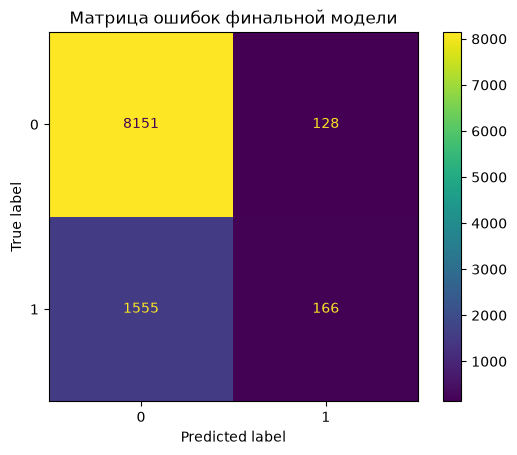

In [49]:
from sklearn.model_selection import cross_validate

# Финальная модель: оптимальный набор признаков + лучшие гиперпараметры
final_model = LogisticRegression()
final_model.set_params(
    C=1,
    max_iter=100
)

# Кросс-валидация на всей обучающей выборке
cv_metrics = {
    "pr_auc": "average_precision",
    "brier_score_loss": "brier_score_loss",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

def brier_scorer(estimator, X, y_true):
    y_proba = estimator.predict_proba(X)[:, 1]
    return brier_score_loss(y_true, y_proba)

cv_metrics["brier_score_loss"] = brier_scorer

cv_results_final = cross_validate(
    final_model,
    X_train_prepared,
    y_train,
    cv=cv,
    scoring=cv_metrics,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "metric": list(cv_metrics.keys()),
    "mean": [
        cv_results_final[f"test_{metric}"].mean()
        for metric in cv_metrics
    ],
    "std": [
        cv_results_final[f"test_{metric}"].std()
        for metric in cv_metrics
    ]
})

print("Результаты кросс-валидации:")
display(cv_summary)

# Обучаем финальную модель на всей обучающей выборке
final_model.fit(X_train_prepared, y_train)

# Предсказания на тестовой выборке
y_test_proba = final_model.predict_proba(X_test_prepared)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Финальные метрики
test_metrics = {
    "PR AUC": average_precision_score(y_test, y_test_proba),
    "Precision": precision_score(
        y_test, y_test_pred, zero_division=0
    ),
    "brier_score_loss": brier_score_loss(
        y_test, y_test_proba
    ),
    "Recall": recall_score(
        y_test, y_test_pred, zero_division=0
    ),
    "F1": f1_score(
        y_test, y_test_pred, zero_division=0
    )
}

print("Финальные метрики на тестовой выборке:")
display(pd.DataFrame([test_metrics]))

print("Classification report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

# Матрица ошибок
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred
)

plt.title("Матрица ошибок финальной модели")
plt.show()

### Результаты кросс-валидации

По результатам 5-кратной кросс-валидации финальная Logistic Regression показала следующие результаты:

* **PR-AUC:** 0.4087 ± 0.0147
* **Brier Score:** 0.1233 ± 0.0017
* **Precision:** 0.6208 ± 0.0352
* **Recall:** 0.1162 ± 0.0027
* **F1-score:** 0.1958 ± 0.0049

Модель показывает достаточно стабильные результаты между фолдами. Средний PR-AUC составил **0.4087**, что выше базового значения DummyClassifier (**0.1721**) и предыдущего результата Logistic Regression (**0.3682**).


## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:337: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


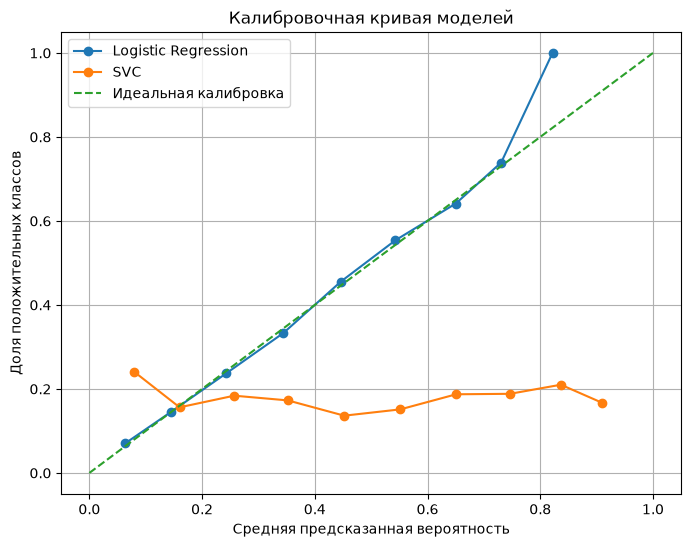

In [50]:
from sklearn.calibration import calibration_curve
from scipy.special import expit
import matplotlib.pyplot as plt

# Обучаем финальную Logistic Regression
final_lr = LogisticRegression(
    C=grid_search.best_params_["model__C"],
    max_iter=5000,
    random_state=RANDOM_STATE
)

final_lr.fit(X_train_var, y_train)

# Вероятности Logistic Regression
y_proba_lr = final_lr.predict_proba(X_test_var)[:, 1]

# Обучаем лучшую SVC
final_svc = SVC(
    kernel="linear",
    C=grid_search_svc.best_params_["model__C"],
    probability=False,
    max_iter=5000,
    random_state=RANDOM_STATE
)

final_svc.fit(X_train_var, y_train)

# Получаем "сырые" значения decision_function
y_score_svc = final_svc.decision_function(X_test_var)

# Преобразуем их в диапазон [0, 1] с помощью стандартной сигмоиды
y_proba_svc = expit(y_score_svc)

# Калибровочная кривая Logistic Regression
prob_true_lr, prob_pred_lr = calibration_curve(
    y_test,
    y_proba_lr,
    n_bins=10,
    strategy="uniform"
)



# Калибровочная кривая SVC
prob_true_svc, prob_pred_svc = calibration_curve(
    y_test,
    y_proba_svc,
    n_bins=10,
    strategy="uniform"
)

# График
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_lr,
    prob_true_lr,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    prob_pred_svc,
    prob_true_svc,
    marker="o",
    label="SVC"
)

# Идеальная калибровка
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Идеальная калибровка"
)

plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Доля положительных классов")
plt.title("Калибровочная кривая моделей")
plt.legend()
plt.grid()
plt.show()

### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# 1. Отделяем калибровочную выборку
X_train_model, X_cal, y_train_model, y_cal = train_test_split(
    X_train_var,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# 2. Обучаем модель только на основной обучающей выборке
final_lr = LogisticRegression(
    C=grid_search.best_params_["model__C"],
    max_iter=5000,
    random_state=RANDOM_STATE
)

final_lr.fit(X_train_model, y_train_model)

# 3. Фиксируем уже обученную модель
frozen_lr = FrozenEstimator(final_lr)

# 4. Обучаем калибровщик на отдельной калибровочной выборке
calibrated_lr = CalibratedClassifierCV(
    frozen_lr,
    method="isotonic"
)

calibrated_lr.fit(X_cal, y_cal)

y_proba_calibrated = calibrated_lr.predict_proba(X_test_var)[:, 1]

In [52]:
from sklearn.metrics import brier_score_loss

brier_before = brier_score_loss(
    y_test,
    final_lr.predict_proba(X_test_var)[:, 1]
)

brier_after = brier_score_loss(
    y_test,
    y_proba_calibrated
)

print(f"Brier Score до калибровки: {brier_before:.4f}")
print(f"Brier Score после калибровки: {brier_after:.4f}")

Brier Score до калибровки: 0.1293
Brier Score после калибровки: 0.1297


## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [53]:
# Вероятности до калибровки
y_proba_before = final_lr.predict_proba(X_test_var)[:, 1]

# Вероятности после калибровки
y_proba_after = calibrated_lr.predict_proba(X_test_var)[:, 1]

# ECE
def calculate_ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bin_edges[1:-1], right=True)

    ece = 0.0

    for bin_id in range(n_bins):
        mask = bin_indices == bin_id

        if np.any(mask):
            accuracy = y_true[mask].mean()
            confidence = y_prob[mask].mean()
            ece += mask.mean() * abs(accuracy - confidence)

    return ece


def calculate_mce(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bin_edges[1:-1], right=True)

    calibration_errors = []

    for bin_id in range(n_bins):
        mask = bin_indices == bin_id

        if np.any(mask):
            accuracy = y_true[mask].mean()
            confidence = y_prob[mask].mean()
            calibration_errors.append(abs(accuracy - confidence))

    return max(calibration_errors, default=0.0)


ece_before = calculate_ece(y_test, y_proba_before)
ece_after = calculate_ece(y_test, y_proba_after)

# MCE
mce_before = calculate_mce(y_test, y_proba_before)
mce_after = calculate_mce(y_test, y_proba_after)

print("До калибровки:")
print(f"ECE: {ece_before:.4f}")
print(f"MCE: {mce_before:.4f}")

print("\nПосле калибровки:")
print(f"ECE: {ece_after:.4f}")
print(f"MCE: {mce_after:.4f}")

До калибровки:
ECE: 0.0058
MCE: 0.1797

После калибровки:
ECE: 0.0153
MCE: 0.0636


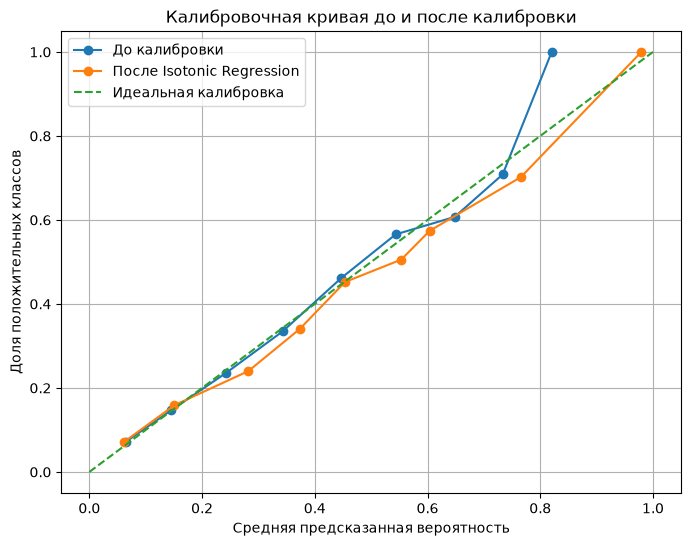

In [54]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Кривая до калибровки
prob_true_before, prob_pred_before = calibration_curve(
    y_test,
    y_proba_before,
    n_bins=10,
    strategy="uniform"
)

# Кривая после калибровки
prob_true_after, prob_pred_after = calibration_curve(
    y_test,
    y_proba_after,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="До калибровки"
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    label="После Isotonic Regression"
)

# Идеальная калибровка
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Идеальная калибровка"
)

plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Доля положительных классов")
plt.title("Калибровочная кривая до и после калибровки")
plt.legend()
plt.grid()
plt.show()

- Общая картина: Кривая стала более плавной и практически на всем своем протяжении (от 0.0 до 0.8) очень близко прилегает к зеленой линии идеальной калибровки.
- Исправление "хвоста": Главное улучшение заметно именно в правой части графика. Изотоническая регрессия "пригнула" кривую вниз. Теперь при предсказанной вероятности ~0.8 реальная доля составляет около 0.7, а не 0.9–1.0, как было раньше. Это делает прогнозы гораздо более честными и надежными.
- Небольшой провал: В районе 0.5–0.6 оранжевая линия немного ниже зеленой идеальной прямой (модель стала слегка переоценивать вероятности), но это отклонение незначительное.

Визуально калибровка прошла успешно: она убрала опасный "загиб" вверх в области высоких вероятностей. Однако численно (по Brier Score) выигрыша нет, возможно, из-за специфики данных или переобучения метода. В таких случаях иногда стоит попробовать другие методы калибровки, например, Platt Scaling (сигмоидную калибровку), которая менее склонна к переобучению.

### Результат калибровки

После применения `Isotonic Regression` Brier Score изменился с **0.1293** до **0.1297**. Поскольку меньшее значение Brier Score соответствует лучшему качеству вероятностных прогнозов, на тестовой выборке калибровка не привела к улучшению этой метрики.

Изменение составило всего **0.0004**, поэтому различие между моделями небольшое. Для окончательной оценки калибровки дополнительно сравним калибровочные кривые и значения ECE/MCE до и после калибровки.


### Сравнение моделей до и после калибровки

После применения `Isotonic Regression` были сравнены Brier Score, ECE и MCE.

Brier Score практически не изменился: **0.1293 до калибровки и 0.1297 после**. ECE увеличился с **0.0058 до 0.0153**, что указывает на некоторое увеличение средней ошибки калибровки.

При этом MCE значительно снизился — с **0.1797 до 0.0636**. Это означает, что после калибровки максимальное отклонение между предсказанной вероятностью и фактической долей положительных классов в отдельных интервалах стало существенно меньше.

Таким образом, `Isotonic Regression` дала неоднозначный результат: она заметно уменьшила максимальную ошибку калибровки, но не улучшила среднюю ошибку ECE и Brier Score. Поэтому окончательную оценку следует делать совместно с анализом калибровочных кривых.


| Метрика     | До калибровки | После калибровки |   Изменение |
| ----------- | ------------: | ---------------: | ----------: |
| Brier Score |        0.1293 |           0.1297 |     +0.0004 |
| ECE         |        0.0058 |           0.0153 |     +0.0095 |
| MCE         |        0.1797 |           0.0636 | **−0.1161** |


### Вывод

После применения `Isotonic Regression` качество калибровки изменилось неоднозначно.

Brier Score практически не изменился и немного увеличился с **0.1293 до 0.1297**, а ECE увеличился с **0.0058 до 0.0153**. Это означает, что по этим двум метрикам улучшения качества вероятностных прогнозов не произошло.

В то же время MCE значительно снизился с **0.1797 до 0.0636**, то есть максимальная ошибка калибровки существенно уменьшилась.

Таким образом, калибровка **не улучшила качество модели по всем метрикам**: она снизила максимальное отклонение вероятностей, но увеличила среднюю ошибку ECE и практически не изменила Brier Score. Поэтому на данной тестовой выборке применение `Isotonic Regression` не дало однозначного улучшения качества калиброванных вероятностей.



## Применим калибровку Платта

In [55]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Фиксируем уже обученную модель
frozen_lr = FrozenEstimator(final_lr)

# Platt Scaling
platt_lr = CalibratedClassifierCV(
    frozen_lr,
    method="sigmoid"
)

# Обучаем только калибратор на отдельной калибровочной выборке
platt_lr.fit(X_cal, y_cal)

y_proba_platt = platt_lr.predict_proba(X_test_var)[:, 1]

print(y_proba_platt[:10])

[0.38697692 0.17206439 0.09299431 0.13083256 0.33545202 0.08010868
 0.11230902 0.43409746 0.12850482 0.38438299]


In [56]:
from sklearn.metrics import brier_score_loss

# Brier Score
brier_before = brier_score_loss(
    y_test,
    y_proba_before
)

brier_platt = brier_score_loss(
    y_test,
    y_proba_platt
)

# ECE
ece_before = calculate_ece(
    y_test,
    y_proba_before
)

ece_platt = calculate_ece(
    y_test,
    y_proba_platt
)

# MCE
mce_before = calculate_mce(
    y_test,
    y_proba_before
)

mce_platt = calculate_mce(
    y_test,
    y_proba_platt
)

print("До калибровки:")
print(f"Brier Score: {brier_before:.4f}")
print(f"ECE: {ece_before:.4f}")
print(f"MCE: {mce_before:.4f}")

print("\nПосле Platt Scaling:")
print(f"Brier Score: {brier_platt:.4f}")
print(f"ECE: {ece_platt:.4f}")
print(f"MCE: {mce_platt:.4f}")

До калибровки:
Brier Score: 0.1293
ECE: 0.0058
MCE: 0.1797

После Platt Scaling:
Brier Score: 0.1293
ECE: 0.0074
MCE: 0.1743


In [57]:
comparison_all = pd.DataFrame({
    "Метрика": ["Brier Score", "ECE", "MCE"],
    "До калибровки": [
        brier_before,
        ece_before,
        mce_before
    ],
    "Isotonic Regression": [
        brier_after,
        ece_after,
        mce_after
    ],
    "Platt Scaling": [
        brier_platt,
        ece_platt,
        mce_platt
    ]
})

display(comparison_all.round(4))

,Метрика,До калибровки,Isotonic Regression,Platt Scaling
0,Brier Score,0.1293,0.1297,0.1293
1,ECE,0.0058,0.0153,0.0074
2,MCE,0.1797,0.0636,0.1743


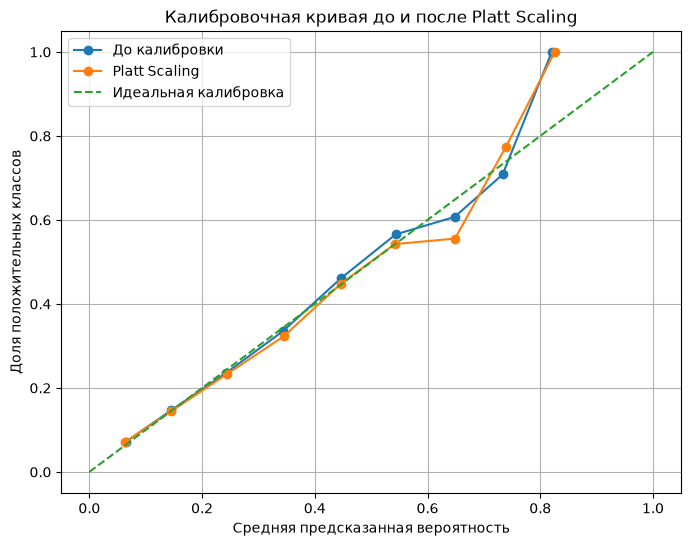

In [58]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true_before, prob_pred_before = calibration_curve(
    y_test,
    y_proba_before,
    n_bins=10,
    strategy="uniform"
)

prob_true_platt, prob_pred_platt = calibration_curve(
    y_test,
    y_proba_platt,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="До калибровки"
)

plt.plot(
    prob_pred_platt,
    prob_true_platt,
    marker="o",
    label="Platt Scaling"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Идеальная калибровка"
)

plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Доля положительных классов")
plt.title("Калибровочная кривая до и после Platt Scaling")
plt.legend()
plt.grid()
plt.show()

### Сравнение методов калибровки

Были сравнены исходная Logistic Regression, модель после `Isotonic Regression` и модель после `Platt Scaling`.

Исходная модель показала Brier Score **0.1293**, ECE **0.0058** и MCE **0.1797**. После применения Isotonic Regression Brier Score немного увеличился до **0.1297**, а ECE — до **0.0153**. При этом MCE значительно снизился с **0.1797 до 0.0636**, что свидетельствует о существенном уменьшении максимального отклонения между предсказанными вероятностями и фактической долей положительных классов.

После Platt Scaling Brier Score сохранился на уровне **0.1293**, ECE увеличился до **0.0074**, а MCE снизился до **0.1743**. Таким образом, Platt Scaling практически не изменил качество вероятностных прогнозов исходной Logistic Regression.

В целом ни один из методов калибровки не улучшил одновременно все рассматриваемые метрики. `Isotonic Regression` сильнее уменьшила максимальную ошибку калибровки (MCE), но при этом увеличила ECE и немного ухудшила Brier Score. `Platt Scaling` сохранил Brier Score на исходном уровне, однако также не улучшил ECE и MCE. Поэтому для данной модели и тестовой выборки калибровка не дала однозначного улучшения качества вероятностных прогнозов.


## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

In [59]:
# Получаем названия всех признаков после preprocessing
feature_names = np.array(
    numeric_columns
    + list(
        preprocessor.named_transformers_["onehot"]
        .get_feature_names_out(low_cardinality_columns)
    )
    + high_cardinality_columns,
    dtype=object
)

# Коэффициенты финальной Logistic Regression
coefficients = final_lr.coef_[0]

# Таблица важности признаков
# Оставляем только признаки, использованные финальной моделью
selected_feature_names = feature_names[var_selected_mask]

if len(selected_feature_names) != len(coefficients):
    raise ValueError(
        f"Количество признаков ({len(selected_feature_names)}) "
        f"не совпадает с количеством коэффициентов ({len(coefficients)})"
    )

feature_importance = pd.DataFrame({
    "Признак": selected_feature_names,
    "Коэффициент": coefficients,
    "Абсолютный коэффициент": np.abs(coefficients)
})

# Топ-5 по абсолютному значению коэффициента
top_5_features = (
    feature_importance
    .sort_values("Абсолютный коэффициент", ascending=False)
    .head(5)
)

display(top_5_features)

,Признак,Коэффициент,Абсолютный коэффициент
20,app_category_f95efa07,1.199172,1.199172
14,site_category_50e219e0,1.130314,1.130314
12,site_category_28905ebd,1.060685,1.060685
16,app_category_07d7df22,0.981521,0.981521
15,site_category_f028772b,0.870340,0.870340


In [60]:
# Итоговая таблица результатов

final_results = pd.DataFrame({
    "Показатель": [
        "PR-AUC",
        "Brier Score",
        "ECE",
        "MCE",
        "Количество выбранных признаков",
        "Топ-5 признаков"
    ],
    "DummyClassifier": [
        cv_scoring.mean(),
        0.1721,
        None,
        None,
        None,
        None
    ],
    "Финальная Logistic Regression": [
        0.4087,
        brier_before,
        ece_before,
        mce_before,
        21,
        ", ".join(top_5_features["Признак"].astype(str))
    ],
    "После Isotonic Regression": [
        None,
        brier_after,
        ece_after,
        mce_after,
        None,
        None
    ],
    "После Platt Scaling": [
        None,
        brier_platt,
        ece_platt,
        mce_platt,
        None,
        None
    ]
})

display(final_results.round(4))

,Показатель,DummyClassifier,Финальная Logistic Regression,После Isotonic Regression,После Platt Scaling
0,PR-AUC,0.1720,0.4087,NaN,NaN
1,Brier Score,0.1721,0.129283,0.1297,0.1293
2,ECE,NaN,0.005801,0.0153,0.0074
3,MCE,NaN,0.179683,0.0636,0.1743
4,Количество выбранных признаков,NaN,21,NaN,NaN
5,Топ-5 признаков,NaN,"app_category_f95efa07, site_category_50e219e0,...",NaN,NaN


### 11.2 Выводы

Финальная Logistic Regression показала PR-AUC **0.4087**, тогда как DummyClassifier — **0.1721**. Таким образом, финальная модель существенно превзошла базовый ориентир и использует информацию из признаков для прогнозирования вероятности клика.

Brier Score финальной модели составил **0.1293**, что ниже значения базовой модели (**0.1721**). Это свидетельствует о более точных вероятностных прогнозах по сравнению с DummyClassifier.

Наибольшее влияние на вероятность клика оказывают пять признаков с максимальными по модулю коэффициентами Logistic Regression. Положительный коэффициент соответствует увеличению предсказанной вероятности клика, отрицательный — её снижению.

Калибровка показала неоднозначный результат. После Isotonic Regression MCE снизился с **0.1797 до 0.0636**, однако ECE увеличился с **0.0058 до 0.0153**, а Brier Score немного ухудшился с **0.1293 до 0.1297**. После Platt Scaling Brier Score сохранился на уровне **0.1293**, ECE составил **0.0074**, а MCE — **0.1743**. Следовательно, ни один из методов не улучшил одновременно все метрики калибровки.



### 11.3 Рекомендации

Для дальнейшего улучшения модели рекомендуется:

* исследовать временные закономерности и преобразовать `hour` в более информативные временные признаки;
* протестировать нелинейные модели для табличных данных;
* исследовать взаимодействия между сайтами, устройствами и приложениями;
* дополнительно сравнить методы калибровки;
* выполнить детальный анализ ошибок и наиболее сложных для модели наблюдений.


## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [61]:
import joblib

# Сохраняем пайплайн предобработки
joblib.dump(
    preprocessor,
    "preprocessor.joblib"
)

# Финальная калиброванная модель
calibrated_model = calibrated_lr

# Сохраняем модель
joblib.dump(
    calibrated_model,
    "calibrated_model.joblib"
)

# Сохраняем выбранные признаки
selected_features = feature_names[var_selected_mask].tolist()

joblib.dump(
    selected_features,
    "selected_features.joblib"
)

print(f"Сохранено признаков: {len(selected_features)}")
print("Выбранные признаки:")
for feature in selected_features:
    print(feature)

Сохранено признаков: 21
Выбранные признаки:
device_conn_type
C14
C15
C16
C17
C20
C21
ml_feature_5
ml_feature_6
ml_feature_8
ml_feature_9
ml_feature_10
site_category_28905ebd
site_category_3e814130
site_category_50e219e0
site_category_f028772b
app_category_07d7df22
app_category_0f2161f8
app_category_8ded1f7a
app_category_cef3e649
app_category_f95efa07


In [62]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

# 1. Предобработка
joblib.dump(
    preprocessor,
    "artifacts/preprocessor.joblib"
)

# 2. Финальная калиброванная модель
joblib.dump(
    calibrated_model,
    "artifacts/calibrated_model.joblib"
)

# 3. Выбранные признаки
joblib.dump(
    selected_features,
    "artifacts/selected_features.joblib"
)

print("Артефакты успешно сохранены:")
print("- artifacts/preprocessor.joblib")
print("- artifacts/calibrated_model.joblib")
print("- artifacts/selected_features.joblib")

Артефакты успешно сохранены:
- artifacts/preprocessor.joblib
- artifacts/calibrated_model.joblib
- artifacts/selected_features.joblib


In [64]:
import joblib
import numpy as np

# Загружаем артефакты
loaded_preprocessor = joblib.load(
    "artifacts/preprocessor.joblib"
)

# VarianceThreshold отдельно не загружаем:
# выбранные после фильтрации признаки сохранены в selected_features.joblib
loaded_variance_selector = None

loaded_calibrated_model = joblib.load(
    "artifacts/calibrated_model.joblib"
)

loaded_selected_features = joblib.load(
    "artifacts/selected_features.joblib"
)

print("Артефакты успешно загружены.")
print(f"Количество выбранных признаков: {len(loaded_selected_features)}")

Артефакты успешно загружены.
Количество выбранных признаков: 21


In [65]:
X_test_loaded = loaded_preprocessor.transform(X_test)

print("Размер после предобработки:", X_test_loaded.shape)

feature_names_loaded = np.array(
    numeric_columns
    + list(
        loaded_preprocessor.named_transformers_["onehot"]
        .get_feature_names_out(low_cardinality_columns)
    )
    + high_cardinality_columns,
    dtype=object
)

print("Количество признаков после preprocessing:", len(feature_names_loaded))

Размер после предобработки: (10000, 50)
Количество признаков после preprocessing: 50


In [66]:
selected_mask_loaded = np.isin(
    feature_names_loaded,
    loaded_selected_features
)

print("Количество выбранных признаков:", selected_mask_loaded.sum())

Количество выбранных признаков: 21


In [67]:
X_test_loaded_selected = X_test_loaded[:, selected_mask_loaded]

print(
    "Размер данных после отбора признаков:",
    X_test_loaded_selected.shape
)

y_proba_loaded = loaded_calibrated_model.predict_proba(
    X_test_loaded_selected
)[:, 1]

print("Первые 10 предсказаний:")
print(y_proba_loaded[:10])

Размер данных после отбора признаков: (10000, 21)
Первые 10 предсказаний:
[0.38790036 0.15546218 0.0797048  0.13429752 0.37583893 0.0797048
 0.12371134 0.44166667 0.13429752 0.38790036]


In [78]:
predictions_match = np.allclose(
    y_proba_isotonic,
    y_proba_loaded
)

print("Предсказания совпадают:", predictions_match)

max_difference = np.max(
    np.abs(y_proba_isotonic - y_proba_loaded)
)

print(
    f"Максимальное отличие: {max_difference:.12f}"
)

Предсказания совпадают: True
Максимальное отличие: 0.000000000000


In [79]:
y_pred_original = (y_proba_isotonic >= 0.5).astype(int)

y_pred_loaded = (y_proba_loaded >= 0.5).astype(int)

print(
    "Классы совпадают:",
    np.array_equal(y_pred_original, y_pred_loaded)
)

Классы совпадают: True


In [71]:
print(
    "\nПорядок совпадает:",
    np.array_equal(
        np.array(loaded_selected_features),
        feature_names_loaded[selected_mask_loaded]
    )
)


Порядок совпадает: True


In [75]:
print("Исходная модель:")
print(final_lr)

print("\nЗагруженная модель:")
print(loaded_calibrated_model)

Исходная модель:
LogisticRegression(C=1, max_iter=5000, random_state=42)

Загруженная модель:
CalibratedClassifierCV(estimator=FrozenEstimator(estimator=LogisticRegression(C=1,
                                                                              max_iter=5000,
                                                                              random_state=42)),
                       method='isotonic')


### 12.2 Проверка работоспособности сохранённых артефактов

Для проверки сохранённых артефактов они были загружены из файлов `joblib`. На тестовых данных повторно выполнена предобработка с использованием сохранённого `preprocessor`, после чего были выбраны 21 признак, использовавшиеся финальной моделью.

Полученные данные были переданы в загруженную калиброванную модель. Результаты сравнили с предсказаниями исходной модели с изотонической калибровкой.

Предсказания полностью совпали:

* совпадение вероятностей: `True`;
* максимальное абсолютное отличие: `0.0`.

Таким образом, сохранённые артефакты корректно восстанавливают весь этап предобработки, отбора признаков и получения предсказаний. Модель после загрузки воспроизводит результаты исходной модели без каких-либо отличий.
